In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns  
import glob

from collections import Counter

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG
from utils import label_mapping_utils as lmu
from utils import nebula_with_factors as deg_nebula

from statsmodels.stats.multitest import multipletests
import gseapy as gp
from gseapy import dotplot, barplot, gseaplot2
print(gp.get_library_name())
import shutil

import decoupler as dc

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline


TISSUE = "DFC" # Striatum, DFC, SN
TYPE_DEG = "baseline_nebula" #PCA_nebula, baseline_nebula. cNMF_nebula gradient_score_nebula
RESULTS_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# How to define significant genes
ALPHA_MULTIPLE_TEST = 0.05
METHOD_MULTIPLE_TEST = "fdr_bh" # fdr_bh, bonferroni, holm, etc. see statsmodels.stats.multitest.multipletests
LOGFC_THR=0.5 #1e-30#0.5 #set your logFC threshold at or above the median SE
PVAL_THR=0.05
PVAL_COL=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
SE_COL=f"se_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL="gene"
COL_P_ADJ = f"adj_{PVAL_COL}"
N_TOP = 20

REMOVE_RIBO_GENES_FROM_GSEA = True  
REMOVE_GENE_TOO_HIGH_INTERCEPT = True # filter out genes with extreme negative intercept logFC, which are likely very lowly expressed in controls and their logFC is unreliable.

# GSEA parameters

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

In [2]:
# Map: cell types that have zone analysis → their zone variable
# each cell type has  a better zonation level
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}
# adata stays untouched here — no more global mutation


# Read grad genes

In [3]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad["combined_p"] <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene", "combined_p"]].rename(columns={"combined_p": "p-value_gradient"})
df_grad

1241
1241


,mean_spearman,is_gradient_gene,p-value_gradient
gene,,,
A1BG,-0.002360,False,5.349057e-07
A1BG-AS1,-0.007881,False,3.198023e-08
A1CF,0.007398,False,2.969691e-02
A2M,-0.002144,False,8.049117e-15
A2M-AS1,-0.000389,False,7.443913e-03
...,...,...,...
ENSG00000277836,NaN,False,NaN
ENSG00000278633,NaN,False,NaN
ENSG00000276017,-0.008289,False,2.949804e-01


# Read Handsaker genes

In [4]:
phase_d = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_d_genes.csv")
phase_c_plus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_plus_genes.csv")
phase_c_minus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_minus_genes.csv")
phase_d
phase_c_minus

,Gene,Phase C p-value,Phase C effect,Phase C fold-change,Phase D p-value,Phase D effect,Pct cells,Phase,Highly expressed C+,Highly expressed C-,De-repressed phase D,Case-control p-value,Case-control fold-change
0,ABAT,2.010000e-13,-0.001111,0.846,1.510000e-01,0.070240,99.90,C-,N,Y,N,1.860000e-02,0.912
1,AC008591.1,8.580000e-12,-0.001579,0.789,2.400000e-02,-0.168123,98.08,C-,N,Y,N,1.200000e-08,0.478
2,AC069437.1,4.680000e-12,-0.001738,0.770,5.780000e-03,-0.221585,95.94,C-,N,Y,N,3.040000e-08,0.398
3,AC079385.1,2.180000e-16,-0.002295,0.709,3.980000e-03,-0.260246,97.20,C-,N,Y,N,2.300000e-06,0.738
4,AC090124.1,1.170000e-29,-0.005723,0.424,9.110000e-02,-0.258410,71.56,C-,N,N,N,1.010000e-09,0.561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,YPEL1,2.960000e-52,-0.002457,0.692,2.250000e-06,-0.239871,99.53,C-,N,Y,N,6.460000e-05,1.263
216,ZMAT4,1.890000e-19,-0.001203,0.835,2.020000e-10,-0.276307,99.96,C-,N,Y,N,9.860000e-01,1.028
217,ZNF83,3.040000e-37,-0.003241,0.615,9.290000e-01,-0.007202,98.47,C-,N,Y,N,4.520000e-02,1.141
218,ZNRF3,5.460000e-12,-0.001219,0.833,3.000000e-02,-0.124679,99.51,C-,N,Y,N,1.650000e-03,0.906


# Create list fof **Folders** to analyse

In [5]:
# Build list of all result folders: (folder_path, label)
# Covers both regular cell types and all zone CTs
_all_results = []

# 1. Regular cell types
for ct in sorted(os.listdir(RESULTS_FOLDER)):

    if ct == "summary":          # ← skip our own output folder
        continue

    d = os.path.join(RESULTS_FOLDER, ct)
    if not os.path.isdir(d) or "_by_" in ct:
        continue
    _all_results.append((d, ct))

# 2. Zone cell types (Striatum only)
if TISSUE == "Striatum":
    for zone_ct, zone_variable in ZONE_CT_MAP.items():
        zone_base = os.path.join(RESULTS_FOLDER, f"{zone_ct}_by_{zone_variable}")
        if not os.path.isdir(zone_base):
            continue
        for zone in sorted(os.listdir(zone_base)):
            d = os.path.join(zone_base, zone)
            if os.path.isdir(d):
                _all_results.append((d, f"{zone_ct}_by_{zone_variable}/{zone}"))

print(f"Found {len(_all_results)} result folders to process")
for d, lbl in _all_results:
    print(f"  {lbl}")

Found 33 result folders to process
  Astrocyte
  COP
  Chandelier
  Endothelial_BBB
  Fibroblasts
  L2
  L4_IT_1
  L4_IT_2
  L4_IT_3
  L4_IT_4
  L5
  L5_ET_C
  L5_IT_A
  L5_IT_B
  L6_CT
  L6_IT
  L6_IT_Car3
  L6b
  Lamp5
  Lamp5_Lhx6
  Lymphocytes
  Macrophages
  Microglia
  OPC
  Oligodendrocyte
  Pax6
  Pericytes
  Pvalb
  SmoothMuscleCells
  Sncg
  Sst
  Vip
  _summary


# Plot Vulcano plots

In [ ]:
import shutil


for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

    #ct="Matrix"
    print("\n######################\n",ct, "\n######################\n")


    # fodle of results
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka
    print(save_csv_path)

    # Saved files
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "images")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
    os.makedirs(img_dir, exist_ok=True)
    
    formatted_save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results_formatted.csv"
    vulcano_plot_path = f"{img_dir}/volcano_plot.png"
    vulcano_plot_only_sig_path = f"{img_dir}/volcano_plot_only_sig.png"
    vulcano_plot_only_interesting_path = f"{img_dir}/volcano_plot_only_interesting.png"

    if not os.path.exists(save_csv_path):
        print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
        continue

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)

    # Add adj pvalue
    # attention: use all genes
    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)  # ln → log2
    df_nebula[COL_P_ADJ] = multipletests(df_nebula[PVAL_COL],method=METHOD_MULTIPLE_TEST)[1]

    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        #extreme negative intercept are likely very lowly expressed in controls and their logFC is unreliable. 
        extreme_intercept = df_nebula["logFC_(Intercept)"] < -20
        print(f"  Removing {extreme_intercept.sum()} genes with extreme intercept logFC")
        df_nebula = df_nebula[~extreme_intercept]

    # Add gradient info
    df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
    df_nebula = df_nebula.rename(columns={"is_gradient_gene": "is_grad_gene"})
    df_nebula = df_nebula.sort_values(COL_P_ADJ)

    # Selec signficant genes
    sig_genes = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[COL_P_ADJ] <= PVAL_THR)][GENE_COL].tolist()
    df_sig = df_nebula[df_nebula[GENE_COL].isin(sig_genes)].copy()
    df_sig = df_sig[[GENE_COL, LOGFC_COL, COL_P_ADJ, "is_grad_gene", "mean_spearman"]]
    #print(df_sig[GENE_COL].to_list())
    #display(df_sig)
    #print(df_sig["is_grad_gene"].sum())

    # Create formatted results 
    df_nebula_formatted = df_nebula[[GENE_COL, LOGFC_COL, PVAL_COL, "logFC_(Intercept)", "is_grad_gene", "mean_spearman"]].copy() # sleect spefici columns
    df_nebula_formatted["is_significant"] = df_nebula_formatted[GENE_COL].isin(sig_genes) # add column for signficant genes
    df_nebula_formatted.to_csv(formatted_save_csv_path, index=False)
    #display(df_nebula_formatted)

    #########
    ### VULCANO PLOT
    ##########
    categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green"),}
    categories_age = {"Age Genes": (["HCN1", "VWC2", "OPRM1", "BACH2", "PCED1B", "MME", "EBF1", "SPON1", "SEMA3E", "SERPINE2", "LINGO2", "GRM8", "KCNK2", "SINHCAF", "DDIT4L", "PTPN7", "PRKD1", "PEX5L", "OPCML", "SHC3", "PDE4B", "SLC24A2", "CCDC39", "FAT2", "CNTN5", "FIGN", "PTPRT", "MGAT4C", "IGF2BP2", "AR", "ETV1", "CDH10", "CORO1C", "SPRED2", "GJD2-DT", "ST3GAL6", "EPHA3", "UBASH3B", "PLEKHA7", "PLD5", "SH3RF3", "DOK5", "DOCK10", "SEMA3D", "KITLG", "SCN11A", "COL19A1", "ZNF732", "UNC13C", "SATB1"], "blue"),}
    categories_handsaker_phases = {
        "Phase D": (phase_d.Gene.to_list(), "blue"),
        "Phase C+": (phase_c_plus.Gene.to_list(), "green"),
        "Phase C-": (phase_c_minus.Gene.to_list(), "cyan"),
        "From Paper": (["PDE10A", "PPP2R2B", "PPP3CA", "PHACTR1", "RYR3", "KCNA4", "KCNAB1", "KCND2", "KCNH1","KCNK1", "KCNQ5", "KCTD1", "HOXA", "HOXB", "HOXC", "HOXD", "HOTAIR", "HOTTIP", "HOTAIRM1", "FOXD1", "LHX9", "ONECUT1", "POU4F2", "SHOX2", "SIX1", "TBX5", "TLX2", "ZIC4", "SLC17A6", "SLC17A7", "SLC6A5", "SLC1A2", "CALB2", "KCNC2", "CDKN2A", "CDKN2B"], "orange")
    }
    categories_general = {
        "TAF1 related genes": (["TAF1", "TIA1", "ZNF772", "SMG7", "ZNF93", "MOV10L1", "EXO1", "SSH", "GLIA1", "OGT", "GLI3"], "red"),
        "Old significant genes": (["SLC7A2", "FKBP5", "ZBTB16", "HIF3A", "NR3C1"], "blue"),
        "PRC2 related genes":([
                                'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
                                'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
                                'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', '4933436C20RIK', 'LECT1', 'ALDH1A7',
                                'PYGL', 'DMRT3', 'TFAP2C', 'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1',
                                'AMN', 'TMEM30B', 'IRX3', 'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3',
                                'SIX6', 'COX6B2', 'TBX2', 'CD44', 'ASB4', 'PTPLAD2', 'SCARF2', 'VGLL2',
                                'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10', 'HOXA9', 'HOXC10', 'SLC6A5',
                                'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9', 'HOXB7', 'HOXB8', 'MNX1',
                                'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2', 'LUM', 'GATA2', 'PMAIP1',
                                'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1', 'FOXL2OS', 'HMX1', 'TBX3',
                                'FOXA1', 'EBF3', 'SIM1', '1500016L03RIK', 'HOXB13', 'EN1', 'SERPINA3N',
                                'RGNEF', 'HOXD13', 'LHX5', 'HOXA7', 'BC061194', 'HOXC5', 'NEUROD1', 'TFAP2A',
                                'HOXB5', 'SHOX2', 'TFAP2B', 'NEUROD2', '2610027K06RIK', 'TLX1', 'TNNT2',
                                'SULT1A1', 'VAX2', '1500011B03RIK', 'RPRD2', 'HOXD11', 'CDKN1A', 'NEUROG2',
                                'EOMES', 'PLIN4', 'TPBG', '4930447C04RIK', 'SSTR3', 'DLK1', 'PRDM8',
                                'E030030I06RIK', 'CES1D', 'HOXA4', 'NRN1', 'VSX2', 'AI448005', 'GFI1',
                                'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2', 'MATN2', 'HOXB3', 'KRT1',
                                'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2', 'HEYL', 'GSTA3', 'NKX2-5',
                                'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4', 'C130021I20RIK', 'SIX1', 'GRP',
                                'COL23A1', 'CIRBP', 'A030001D16RIK', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
                                'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'UGT1A1', 'UGT1A10', 'UGT1A2', 'UGT1A5',
                                'UGT1A6A', 'UGT1A6B', 'UGT1A7C', 'UTG1A9', 'ISLR', 'ASB5', 'MYCL1',
                                'TRP53I11', 'SDC1', '9530018H14RIK', 'GATA4', 'BEND5', 'GM15453', 'RBM3',
                                'FXYD7', 'FOXL2', '1700109F18RIK', 'GM8350', 'ZFP644', '4933439C10RIK',
                                'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25', 'CLDN3', 'SLC6A7', 'SERPINB1B',
                                'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD', 'GALNTL1', 'GNA13', 'ALX1',
                                'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1', 'CPA6', 'DMRT2',
                                'CPNE6', '9330171B17RIK', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
                                'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2'
                            ], "purple"),
        "Could relate to XDP": (
                            [
                            # Primary disease locus genes (Xq13.1)
                            "TAF1", "OGT", "OGA", "ACRC", "CXCR3", "NONO", "ING2", "NLGN3", "GJB1", "ZNF261", "ITGB1BP2",
                            
                            # Direct TAF1 protein interactors (TFIID complex)
                            "TBP", "TAF2", "TAF3", "TAF4", "TAF5", "TAF6", "TAF7", "TAF8", "TAF9", "TAF10", "TAF11", "TAF12", "TAF13",
                            
                            # TAF1 kinase/ubiquitin substrates and binding partners
                            "TP53", "MDM2", "RB1", "AR", "JUN", "CCND1", "CCNA2",
                            
                            # General Transcription Factors (PIC assembly)
                            "GTF2B", "GTF2A1", "GTF2A2", "GTF2E1", "GTF2E2", "GTF2F1", "GTF2F2", "GTF2H1", "GTF2H2", "GTF2H3", "GTF2H4", "GTF2H5", "TCEA1", "ERCC2", "ERCC3",
                            
                            # TAF1 in MLL1 complex
                            "KMT2A", "ASH2L", "HCFC1", "WDR5", "RBBP5",
                            
                            # Striatal signaling breakdown (dysregulated in XDP brain)
                            "DRD2", "DRD1", "PDE10A", "GNAL",
                            
                            # DSC3-affected downstream genes (vesicular transport, dopamine, synapse)
                            "SYP", "SNAP25", "RAB26", "RAB27B", "RAB8B", "DDC", "GCH1", "SLC18A2", "SYT7", "DLG4", "SNAP91", "DBH", "SYTL2", "SLC5A3", "EFNB1",
                            
                            # NFkB pathway and inflammatory targets (altered in XDP fibroblasts)
                            "RELA", "NFKB1", "NFKB2", "IKBKB", "IKBKG", "TNFAIP6", "IL8",
                            
                            # Repeat instability modifiers (shared with HD)
                            "MSH3", "PMS2",
                            
                            # Spliceosome and RNA metabolism (altered in XDP MSNs)
                            "SRSF2", "DHX15", "DHX9", "FUS", "GEMIN5", "HRNPU", "NOVA1", "PAPOLA", "PRPF6", "SART3", "SRSF5", "RALY", "U2AF1L5",
                            
                            # Translational machinery (compensatory upregulation in XDP MSNs)
                            "BMS1", "TRMT5",
                            
                            # SVA retrotransposon repression machinery (KRAB-ZNF / TRIM28 axis)
                            "ZNF91", "TRIM28", "ZNF93", "SETDB1", "DNMT3A", "DNMT3B",
                            
                            # LINE-1 mobilization machinery (SVA is L1-dependent)
                            "L1RE1",
                            
                            # NMD pathway (degrades TAF1-32i intron retention isoform)
                            "UPF1", "UPF2", "UPF3B",
                            
                            # Chromatin immunomodulatory (SVA heterochromatin)
                            "KMT5C", "CIITA",
                            
                            # TAF1 paralog
                            "TAF1L"
                            ], 
                            "orange"),
    }

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=0, # FROCE TO SEE ALL
        to_label=0, 
        categories=categories_general,
        max_y=None,
        ax=ax1,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_spatial,
        max_y=None,
        ax=ax2,
        print_labels=False,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_age,
        max_y=None,
        ax=ax3,
        print_labels=True,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_handsaker_phases,
        max_y=None,
        ax=ax4,
        print_labels=True,
    )

    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=1e-20, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax5, 
    )

    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=LOGFC_THR, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax6, 
    )

    title = f"Volcano – {ct} – {TISSUE} – {TYPE_DEG}"
    for ax, lbl in zip(
        [ax1, ax2, ax3, ax4, ax5, ax6],
        ["Interesting Genes", "Gradient Genes", "Age Genes", "Significant Genes", "Significant Genes", "Significant Genes"] 
    ):        
        ax.set_title(f"{title} [{lbl}]", fontsize=10)

    # fig.canvas.draw()
    # saved_figs[ct] = fig
    
    plt.tight_layout() 


    plt.savefig(vulcano_plot_path, dpi=150, bbox_inches="tight")

    extent = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_interesting_path, bbox_inches=extent, dpi=150)
    extent = ax6.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_sig_path, bbox_inches=extent, dpi=150)

    plt.show()


   

# Make summary csv

Saves to `.../DEG/{TISSUE}/{METHOD}/summary/`:

| File | Content |
|------|---------|
| `all_cell_types.csv` | all regular cell types |
| `by_zone.csv` | CTs split by zone (Striatum only) |
| `by_zone_4.csv` | CTs split by zone_4 (Striatum only) |

Columns: `cell_type` · `gene` · `logFC` · `adj_pvalue` (fdr_bh) · `raw_pvalue`


To copy sumamri on bcuker

```bash
for tissue in Striatum DFC SN; do
  for method in cNMF_nebula baseline_nebula PCA_nebula; do
    gsutil -m cp -r \
      /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/${tissue}/${method}/_summary \
      gs://macosko_data/gdallagl/NucSeq/DEG_results/${tissue}/${method}/
  done
done

```

In [ ]:
BASE   = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"
OUT    = os.path.join(BASE, "_summary")
if os.path.exists(OUT):
    shutil.rmtree(OUT)
os.makedirs(OUT, exist_ok=True)

def read_ct(csv_path, cell_type_label):
    df = pd.read_csv(csv_path).dropna(subset=[PVAL_COL, LOGFC_COL])
    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)  # ln → log2
    df["adj_pvalue"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1] 
    df = pd.DataFrame({
        "cell_type": cell_type_label,
        "gene":      df["gene"],
        "logFC":     df[LOGFC_COL],
        "adj_pvalue":df["adj_pvalue"],
        "raw_pvalue":df[PVAL_COL],
    })
    df = df.merge(df_grad[["mean_spearman", "p-value_gradient", "is_gradient_gene"]], how="left", left_on="gene", right_index=True)
    return df

regular, by_zone, by_zone_4 = [], [], []

for ct_dir in sorted(os.listdir(BASE)):
    ct_path = os.path.join(BASE, ct_dir)
    if not os.path.isdir(ct_path):
        continue

    if "_by_zone_4" in ct_dir:
        target = by_zone_4
    elif "_by_zone" in ct_dir:
        target = by_zone
    else:
        target = regular

    if target is regular:
        csv = os.path.join(ct_path, "deg_results.csv")
        if os.path.isfile(csv):
            regular.append(read_ct(csv, ct_dir))
    else:
        for zone_num in sorted(os.listdir(ct_path)):
            csv = os.path.join(ct_path, zone_num, "deg_results.csv")
            if os.path.isfile(csv):
                target.append(read_ct(csv, f"{ct_dir}/{zone_num}"))

for name, dfs in [("all_cell_types", regular), ("by_zone", by_zone), ("by_zone_4", by_zone_4)]:
    if dfs:
        out_path = os.path.join(OUT, f"{name}.csv")
        pd.concat(dfs, ignore_index=True).to_csv(out_path, index=False)
        print(f"Saved {name}.csv  ({len(dfs)} cell-type blocks) → {out_path}")


# Most frequent genes
df_all = pd.read_csv(f"{OUT}/all_cell_types.csv")
sig = df_all[(df_all["adj_pvalue"] <= PVAL_THR) & (df_all["logFC"].abs() >= LOGFC_THR)]
gene_ct_count = sig.groupby("gene")["cell_type"].nunique().sort_values(ascending=False)
print(gene_ct_count.head(30))  # genes significant in most cell types



Saved all_cell_types.csv  (12 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/_summary/all_cell_types.csv
Saved by_zone.csv  (10 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/_summary/by_zone.csv
Saved by_zone_4.csv  (16 cell-type blocks) → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/_summary/by_zone_4.csv
gene
ARHGAP6            6
ENSG00000291090    5
FKBP5              5
FXYD6              5
HCP5               5
NPNT               5
SASH1              5
ARHGAP18           5
SLC9A2             5
HLA-A              5
FAM106A            5
LPL                5
MAML2              5
ENSG00000236948    5
HDAC9              4
FHIP1A             4
HCN1               4
ADCY1              4
TESPA1             4
DDIT4L             4
STXBP6             4
TMC2               4
DPP10              4
DNAH14             4
ENSG00000287865    4
ENSG00000227681    4
ENSG00000286746  

# GSEA on DEGs genes

In [ ]:
# chekc which libraires
gp.get_library_name()

In [ ]:
# Homemade genesets

#Gradient genes (split by direction)
custom_gene_sets = {
    "Gradient_DorsalVentral": grad_genes,   # all gradient genes
    "Gradient_Dorsal":  df_grad[(df_grad.mean_spearman < 0) & (df_grad.is_gradient_gene)].index.tolist(),  # positive spearman
    "Gradient_Ventral": df_grad[(df_grad.mean_spearman > 0) & (df_grad.is_gradient_gene)].index.tolist(),  # negative spearman
    "PhaseD_genes":     phase_d["Gene"].dropna().tolist(),
    "PhaseC+_genes":   phase_c_plus["Gene"].dropna().tolist(),
    "PhaseC-_genes":   phase_c_minus["Gene"].dropna().tolist(),
    "polycomb": lmu.prc2_genes,
    "mix_handsaker": lmu.handsaker_genes,
    "xdp_related": lmu.xdp_genes,
}
print({k: len(v) for k, v in custom_gene_sets.items()})  # check sizes


{'Gradient_DorsalVentral': 1241, 'Gradient_Dorsal': 550, 'Gradient_Ventral': 691, 'PhaseD_genes': 719, 'PhaseC+_genes': 327, 'PhaseC-_genes': 220, 'polycomb': 140, 'mix_handsaker': 37, 'xdp_related': 115}


In [ ]:
collections_gsea = [
    ("custom",                               custom_gene_sets,                                    custom_gene_sets,                   1,    5000),
    ("MSigDB_Hallmark_2020",                 ["MSigDB_Hallmark_2020"],                              gp.get_library("MSigDB_Hallmark_2020"),              4,  250),
    ("SynGO_2024",                           ["SynGO_2024"],                                        gp.get_library("SynGO_2024"),              4,  250),
    ("Reactome_Pathways_2024",               ["Reactome_Pathways_2024"],                          gp.get_library("Reactome_Pathways_2024"),             4,  250),
    ("GO_Biological_Process_2025",           ["GO_Biological_Process_2025"],                      gp.get_library("GO_Biological_Process_2025"),         4,  250),
    ("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X", ["ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"], gp.get_library("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"), 4, 250),
    ("TRRUST_Transcription_Factors_2019",    ["TRRUST_Transcription_Factors_2019"],               gp.get_library("TRRUST_Transcription_Factors_2019"),  4,  250),
]


2026-04-15 15:19:30 | [INFO] Downloading and generating Enrichr library gene sets...
2026-04-15 15:19:30 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file
2026-04-15 15:19:30 | [INFO] Downloading and generating Enrichr library gene sets...
2026-04-15 15:19:30 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.SynGO_2024.gmt, use local file
2026-04-15 15:19:30 | [INFO] Downloading and generating Enrichr library gene sets...
2026-04-15 15:19:30 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-04-15 15:19:30 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0
2026-04-15 15:19:31 | [INFO] Downloading and generating Enrichr library gene sets...
2026-04-15 15:19:31 | [INFO] Library is already downloaded in: /home/gdallagl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local fi

In [ ]:
def filter_noisy_genes(ranked_series, verbose=True):

    import re

    n_before = len(ranked_series)

    # ── Regex approach ─────────────────────────────────────────────────
    # Covers the most common non-informative gene classes in snRNA-seq
    _pattern = re.compile(r"""^(
        RPL   | RPS   | MRPL  | MRPS  |  # ribosomal proteins (cytoplasmic + mitochondrial)
        MT-                            |  # mitochondrial protein-coding genes
        LINC                           |  # long intergenic non-coding RNA
        SNHG  | SNORA | SNORD          |  # small nucleolar RNA host genes / snoRNAs
        MIR[0-9]                       |  # microRNAs (MIR followed by number)
        RNU                            |  # small nuclear RNAs
        AL[0-9] | AC[0-9] | AP[0-9]   |  # Ensembl unnamed non-coding loci
        ENSG                              # unmapped Ensembl IDs
    )""", re.IGNORECASE | re.VERBOSE)

    noisy = [g for g in ranked_series.index if _pattern.match(g)]
    ranked_series = ranked_series.drop(index=noisy)

    n_removed = n_before - len(ranked_series)
    if verbose:
        print(f"  filter_noisy_genes: removed {n_removed} genes  "
              f"({n_before} → {len(ranked_series)} remaining)")

    return ranked_series

def from_deg_df_to_df_rank(df, GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col=None, REMOVE_GENE_TOO_HIGH_INTERCEPT=True, REMOVE_RIBO_GENES_FROM_GSEA=True, intercept_logfc_col="logFC_(Intercept)"):

    df_rank = df.copy()
    
    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        # extreme negative intercept → very lowly expressed in controls, logFC unreliable
        extreme_intercept = df_rank[intercept_logfc_col] < -20
        print(f"  [filter] Removed {extreme_intercept.sum()} genes with extreme intercept logFC (< -20)")
        df_rank = df_rank[~extreme_intercept]

    # if score is not porviced we msut claculted it
    if score_col is None:
        if PVAL_COL is None or LOGFC_COL is None:
            raise ValueError("Must provide either score_col or both PVAL_COL and LOGFC_COL")
        
        df_rank = df_rank.dropna(subset=[PVAL_COL, LOGFC_COL])

        # DEFINE RANK METRIC
        # Options:
        #   sign(logFC) * -log10(p_raw)   ← direction from sign only
        #   logFC * -log10(p_raw)         ← direction + magnitude from logFC (current)
        #   logFC / SE                    ← t-statistic style
        # ATTENTION: use     p-values — GSEA does its own permutation-based multiple testing
        df_rank["rank_metric"] = (
            df_rank[LOGFC_COL] *
            -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
        )
    else:
        if score_col not in df_rank.columns:
            raise ValueError(f"score_col '{score_col}' not found in DataFrame")
        df_rank["rank_metric"] = df_rank[score_col]

    # Sort descending so most-upregulated genes are at the top
    df_rank = df_rank.sort_values("rank_metric", ascending=False)

    # ── Build the Series for GSEA (gene name as index, rank_metric as values) ──
    ranked_series = df_rank.set_index(GENE_COL)["rank_metric"]

    # Remove non coding genes
    if REMOVE_RIBO_GENES_FROM_GSEA:

        ranked_series = filter_noisy_genes(ranked_series,verbose=True)
        
        # Keep df_rank in sync: only retain genes that survived the filter
        surviving_genes = ranked_series.index
        df_rank = df_rank[df_rank[GENE_COL].isin(surviving_genes)]

    # ranked_series → input to gp.prerank (Series, gene as index)
    # df_rank       → full DataFrame for ORA background, leading-edge logFC lookup, adj p-val computation
    return ranked_series, df_rank

In [ ]:
import shutil


THR_FDR_GSEA=0.05

THR_FDR_ORA = 0.05   # FDR threshold for significant ORA terms
THR_FDR_DEG = 0.05   # FDR threshold for calling a gene a DEG (input to ORA)
THR_LOGFC   = 0.50   # |logFC| threshold for calling a gene a DEG

for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

    #ct="Astrocyte"  
    print(f"\n{'='*60}\n  CELL TYPE: {ct}\n{'='*60}")

    # file wiht deg results
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka

    if not os.path.exists(save_csv_path):
        print(f"  [ERROR] Missing results file: {save_csv_path}")
        continue

    # Save folder
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "gsea_on_degs")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)   # wipe all existing contents
    os.makedirs(img_dir, exist_ok=True)  # create output folder

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)

    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)  # ln → log2

    #########
    ### GSEA
    ##########

    # sereis for GSE, df for other analyssi
    ranked_series, df_rank = from_deg_df_to_df_rank(df_nebula, GENE_COL=GENE_COL, PVAL_COL=PVAL_COL, LOGFC_COL=LOGFC_COL, score_col=None,REMOVE_GENE_TOO_HIGH_INTERCEPT=REMOVE_GENE_TOO_HIGH_INTERCEPT, REMOVE_RIBO_GENES_FROM_GSEA=REMOVE_RIBO_GENES_FROM_GSEA)

    print(f"  [rank]   {len(ranked_series)} genes in final ranked list (top: {ranked_series.index[0]} {ranked_series.iloc[0]:+.2f}, bottom: {ranked_series.index[-1]} {ranked_series.iloc[-1]:+.2f})")
    display(ranked_series)

    #each database is corrected only against itself, and a real signal in Hallmark isn't penalized by the 7,000 GO terms
    #The tradeoff is that you can't directly compare FDR values across databases 
    for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:

        try:

            print(f"\n  {'─'*50}")
            print(f"  GSEA  ▶  {db_name}")
            print(f"  {'─'*50}")
            # ES --> enriuchemnt score
            # NES -->romalised ES --> by gene set size
            # ignificance is assessed by randomly permuting the gene order --> creating nulld sitruvtion
            pre_res = gp.prerank(
                rnk=ranked_series,
                gene_sets=gene_sets,
                seed=42,
                permutation_num=1000,
                min_size=min_s, #if fewer than 10 genes in the set are present in your data, skip it.
                max_size=max_s, #if more than 500 genes in the set overlap your data, skip it
                verbose=False,
                threads=30#24
            )

            # df gsea
            df_gsea = pre_res.res2d.copy()
            df_gsea = df_gsea.sort_values("FDR q-val")

            # Selct only signficant pathways
            df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy() # no NES direction filtering, both nge and psoo

            # save full + significant results (mirrors factor GSEA saving)
            df_gsea.to_csv(    f"{img_dir}/{db_name}_gsea_all.csv", index=False)
            df_gsea_sig.to_csv(f"{img_dir}/{db_name}_gsea_sig.csv", index=False)

            print(f"  [result] {len(df_gsea)} pathways tested  →  {len(df_gsea_sig)} significant (FDR ≤ {THR_FDR_GSEA})")

            # Dispaly
            with pd.option_context('display.max_colwidth', None):
                display(df_gsea_sig[["Term", "NES", "FDR q-val"]])

            # Summary dotplot
            if len(df_gsea_sig) == 0:
                print(f"  [plot]   Skipping dotplot — no significant terms")
            else:

                # Dotplot: size = gene ratio, color = FDR
                try:
                    res2d_plot = df_gsea.copy()
                    res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)  # avoid colormap crash when all FDR=0
                    dotplot(
                        res2d_plot,
                        column="FDR q-val",      # color axis
                        #title="Hallmark pathways",
                        cmap=plt.cm.viridis,
                        size=6,
                        figsize=(10, 5),
                        cutoff=THR_FDR_GSEA,  # only show terms below this FDR
                        show_ring=False,
                        ofname=None, # image saving apth
                    )
                    plt.title(f"{ct} / {db_name}")
                    plt.savefig(f"{img_dir}/{db_name}_dotplot.png", dpi=150, bbox_inches="tight")
                    plt.show()
                    plt.close()
                except Exception as plot_err:
                    print(f"  [plot]   Dotplot failed ({plot_err}), results already saved to CSV")


            #######################
            ### Leading Edge Analysis
            #######################

            print(f"\n  [leading edge]  {db_name}")

            # which specific genes in the gene set are actually driving the enrichment?
            # gene set that appear before the peak of the enrichment score in the ranked list.

            # ── 1. Parse leading edge genes ───────────────────────────────────────────

            # form signficnat apthways
            # leecte teh elading genes (need to be parsed for  df col)
            df_gsea_sig["lead_genes"] = (
                df_gsea_sig["Lead_genes"]
                .str.split(";")
                .apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])
            )
            df_gsea_sig["n_lead"] = df_gsea_sig["lead_genes"].apply(len)

            # # print df (note LEADING GENE already there)
            # with pd.option_context("display.max_colwidth", None):
            #     display(df_gsea_sig[["Term", "NES", "FDR q-val", "Tag %", "n_lead", "Lead_genes"]])

            # ── 2. Genes recurring across ≥2 pathways → highest-confidence hits ───────
            gene_freq = Counter(g for genes in df_gsea_sig["lead_genes"] for g in genes)
            df_gene_freq = pd.DataFrame(gene_freq.most_common(), columns=["gene", "n_pathways"])
            print(f"  [leading edge]  genes in ≥2 pathways: {(df_gene_freq['n_pathways'] > 1).sum()}")
            display(df_gene_freq[df_gene_freq["n_pathways"] > 1])

            # save leading edge frequency table
            df_gene_freq.to_csv(f"{img_dir}/{db_name}_leading_edge_freq.csv", index=False)

            # ── 3. Heatmap: pathways × recurring genes ────────────────────────────────
            # Color  = logFC  →  red = up, blue = down
            # X-axis = genes ordered by DEG rank metric (most up → most down)

            recurring_genes = df_gene_freq[df_gene_freq["n_pathways"] > 1]["gene"].tolist()

            if not recurring_genes:
                print("  [leading edge]  No recurring genes — skipping heatmap")
            else:
                # order genes by rank metric (most up → most down), same order as GSEA list
                gene_order = (
                    df_rank.set_index(GENE_COL)["rank_metric"]
                    .loc[lambda s: s.index.isin(recurring_genes)]
                    .sort_values(ascending=False).index.tolist()
                )

                # logFC if gene in leading edge, NaN (→ grey) otherwise
                matrix = pd.DataFrame(np.nan, index=df_gsea_sig["Term"], columns=gene_order)
                for _, row in df_gsea_sig.iterrows():
                    for gene in set(row["lead_genes"]) & set(gene_order):
                        matrix.loc[row["Term"], gene] = df_rank.set_index(GENE_COL).loc[gene, LOGFC_COL]

                vmax = np.nanmax(np.abs(matrix.values))
                fig, ax = plt.subplots(figsize=(max(8, len(gene_order)*0.45), max(3, len(matrix)*0.5)))
                sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                            linewidths=0.5, linecolor="lightgrey",
                            cbar_kws={"label": "log2FC", "shrink": 0.6}, ax=ax)
                ax.set_title(f"Leading Edge — {ct} / {db_name}")
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
                ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
                plt.tight_layout()
                plt.savefig(f"{img_dir}/{db_name}_leading_edge_heatmap.png", dpi=150, bbox_inches="tight")
                plt.show(); plt.close(fig)

        except Exception as e:
            print(f"  [ERROR]  GSEA failed for {ct} / {db_name}: {e}")

    # #########
    # ### ORA
    # ##########
    # ### ORA — Over-Representation Analysis (fully local)
    # # Hypergeometric test: are my significant DEGs over-represented in a pathway?

    # print(f"\n  {'='*50}")
    # print(f"  ORA  ▶  {ct}")
    # print(f"  {'='*50}")

    # ora_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "ora_on_degs")
    # if os.path.exists(ora_dir): shutil.rmtree(ora_dir)
    # os.makedirs(ora_dir)

    # # background = genes in the ranking (ribo-filtered if applicable)
    # background = ranked_series.index.tolist()

    # # recompute adj p-values on df_rank (already filtered, consistent with background)
    # df_rank["adj_pvalue"] = multipletests(df_rank[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]

    # # restrict DEGs to genes in background (foreground must be subset of background)
    # df_bg    = df_rank[df_rank[GENE_COL].isin(background)]
    # sig_up   = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] >  THR_LOGFC)][GENE_COL].tolist()
    # sig_down = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] < -THR_LOGFC)][GENE_COL].tolist()
    # print(f"  [DEGs]   {len(sig_up)} up  |  {len(sig_down)} down  |  background: {len(background)} genes")

    # for direction, gene_list in [("up", sig_up), ("down", sig_down)]:

    #     if len(gene_list) < 5:
    #         print(f"  [ORA {direction}]  Too few DEGs ({len(gene_list)} < 5) — skipping"); continue

    #     for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:
    #         try:
    #             enr        = gp.enrich(gene_list=gene_list, gene_sets=gs_dict, background=background,
    #                                    outdir=None, no_plot=True, verbose=False)
    #             df_ora     = enr.res2d.sort_values("Adjusted P-value")
    #             df_ora_sig = df_ora[df_ora["Adjusted P-value"] <= THR_FDR_ORA]

    #             df_ora.to_csv(    f"{ora_dir}/ORA_{direction}_{db_name}_all.csv", index=False)
    #             df_ora_sig.to_csv(f"{ora_dir}/ORA_{direction}_{db_name}_sig.csv", index=False)
    #             print(f"  [ORA {direction}]  {db_name}:  {len(df_ora)} tested  →  {len(df_ora_sig)} significant (FDR ≤ {THR_FDR_ORA})")
    #             with pd.option_context("display.max_colwidth", None):
    #                 display(df_ora_sig[["Term", "Overlap", "Adjusted P-value", "Genes"]].head(10))

    #             if df_ora_sig.empty: continue
    #             try:
    #                 dotplot(enr.res2d, column="Adjusted P-value", cutoff=THR_FDR_ORA, top_term=20,
    #                         figsize=(8, max(3, len(df_ora_sig)*0.35)),
    #                         title=f"ORA {direction} — {ct} / {db_name}",
    #                         cmap=plt.cm.viridis, show_ring=False, marker="o")
    #                 plt.savefig(f"{ora_dir}/ORA_{direction}_{db_name}_dotplot.png", dpi=150, bbox_inches="tight")
    #                 plt.show(); plt.close()
    #             except Exception as e:
    #                 print(f"  [plot]   ORA dotplot failed: {e}")

    #         except Exception as e:
    #             print(f"  [ERROR]  ORA {direction} / {db_name} failed: {e}")

            
    #break  # DEBUG: remove to run all cell types

# GSEA on Factors

In [ ]:
#Addtionla short path to test

small_curated_pathways = {
    "Oligodendrocyte_WM":                ["OPALIN"],
    "Oligodendrocyte_GM":                ["PLEKHG1"],
    "Oligodendrocyte_Reactive":          ["FRY", "BCAS1", "HSPA1A"],
    "Oligodendrocyte_Cortisol":          ["FKBP5", "TSC22D3", "SGK1"],

    "Astrocyte_WM":                      ["GFAP", "CRYAB", "VIM"],
    "Astrocyte_GM":                      ["SLC1A2", "SLC1A3", "GJA1", "ALDH1L1"],
    "Astrocyte_A1_Reactive":             ["C3", "SERPING1", "GBP2", "SRGN", "AMIGO2"],
    "Astrocyte_A2_Antiinflammatory":     ["S100A10", "PTX3", "EMP1", "CD14", "SPHK1"],
    "Astrocyte_Cortisol":                ["FKBP5", "TSC22D3", "SGK1"],

    "Microglia_Homeostatic":             ["CX3CR1", "P2RY12", "TMEM119", "HEXB", "CSF1R"],
    "Microglia_DAM":                     ["GPNMB", "TREM2", "SPP1", "LPL", "CD9", "APOE"],

    "General_Mito":                      ["MT-CO1", "MT-CO2", "MT-ND1", "MT-ND3", "MT-ATP6", "MT-CYB"],
    "General_Housekeeping":              ["GAPDH", "ACTB", "B2M"],
    "General_Cortisol":                  ["FKBP5", "TSC22D3", "SGK1", "PER1", "ZBTB16"],
    "General_Hypoxia":                   ["HIF1A", "VEGFA", "LDHA", "SLC2A1"],
    "General_Stress_HSP":                ["HSPA1A", "HSPA1B", "HSPB1", "HSP90AA1", "DNAJB1"],
    "General_CellCycle":                 ["MKI67", "CENPA", "TOP2A", "PCNA", "CDK1", "MCM2"],
    "General_lncRNA":                    ["MALAT1", "NEAT1", "XIST"],
    "General_ImmediateEarlyGenes":       ["FOS", "JUN", "ARC", "FOSB", "JUNB", "EGR1", "NPAS4"],

    "Oligodendrocyte_Markers":           ["MOG", "OLIG1", "OPALIN", "MBP", "PLP1", "CNP", "LGALS1", "PALM2"],
    "Astrocyte_Markers":                 ["GFAP", "AQP4", "ALDH1L1", "S100B", "SOX9", "SLC1A2"],
    "Microglia_Markers":                 ["C1QA", "C1QB", "CX3CR1", "P2RY12", "TREM2", "TMEM119", "AIF1", "CSF1R", "HEXB"],
}


  CELL TYPE: Astrocyte


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7
gene_symbol,,,,,,,
LINC02593,0.016050,-0.006429,-0.006375,0.000286,-0.005454,-0.024187,0.029359
SAMD11,0.027681,0.003923,-0.008094,0.011895,-0.010067,-0.040987,0.047280
HES4,-0.012841,0.016408,0.026925,-0.032724,0.023932,-0.010475,0.017623
ISG15,0.005307,0.021456,0.044799,-0.008782,-0.016874,0.002423,-0.004392
CDK11B,0.007972,-0.000784,0.016513,0.008466,-0.011315,-0.000321,0.004014


,factor,direction,rank,gene,score
0,PC_1,top,1,DCLK1,0.075528
1,PC_1,top,2,CCDC85A,0.071373
2,PC_1,top,3,LINC01088,0.068883
3,PC_1,top,4,ADAMTSL3,0.064904
4,PC_1,top,5,C8orf34,0.064808
...,...,...,...,...,...
275,PC_7,bottom,16,MAP3K19,-0.068838
276,PC_7,bottom,17,TRPC6,-0.070101
277,PC_7,bottom,18,DNAH11,-0.074444
278,PC_7,bottom,19,SYNE1,-0.086062



  ──────────────────────────────────────────────────
  FACTOR: PC_1
  ──────────────────────────────────────────────────


gene
DCLK1        0.075528
CCDC85A      0.071373
LINC01088    0.068883
ADAMTSL3     0.064904
C8orf34      0.064808
               ...   
GRM3        -0.060157
CABLES1     -0.062058
GPC5        -0.066018
NRXN1       -0.071408
SLC1A2      -0.072341
Name: rank_metric, Length: 3000, dtype: float64

...


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


2026-04-15 18:05:45,919 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
1,MSigDB_Hallmark_2020__TGF-beta Signaling,1.610549,0.048334


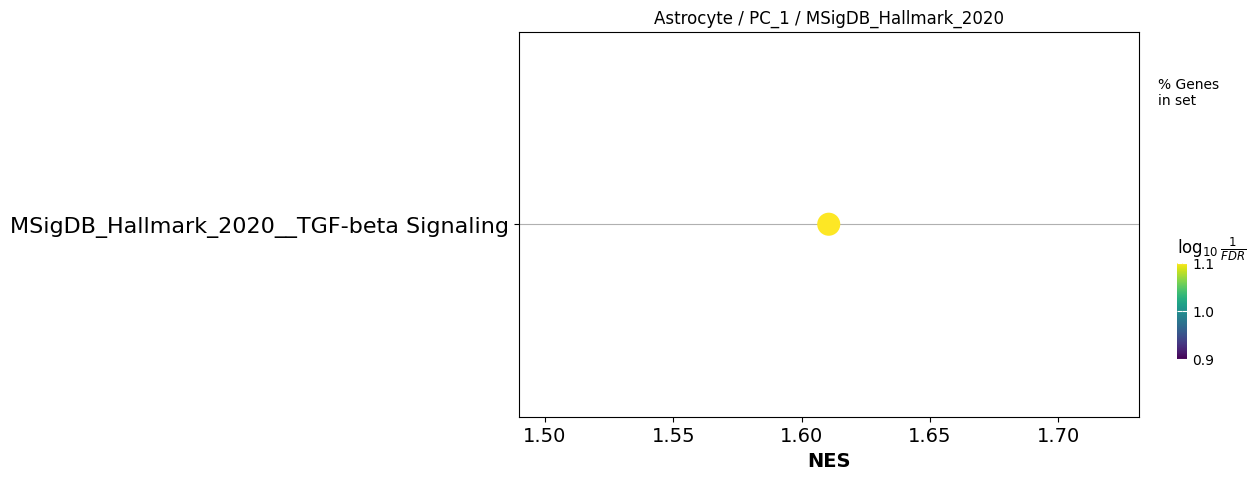

2026-04-15 18:05:46,501 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  4 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,-2.728665,0.0
1,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,-2.370666,0.0
2,SynGO_2024__Presynaptic Ribosome CC,-2.370666,0.0
3,SynGO_2024__Translation At Presynapse (GO:0140236) BP,-2.370666,0.0


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


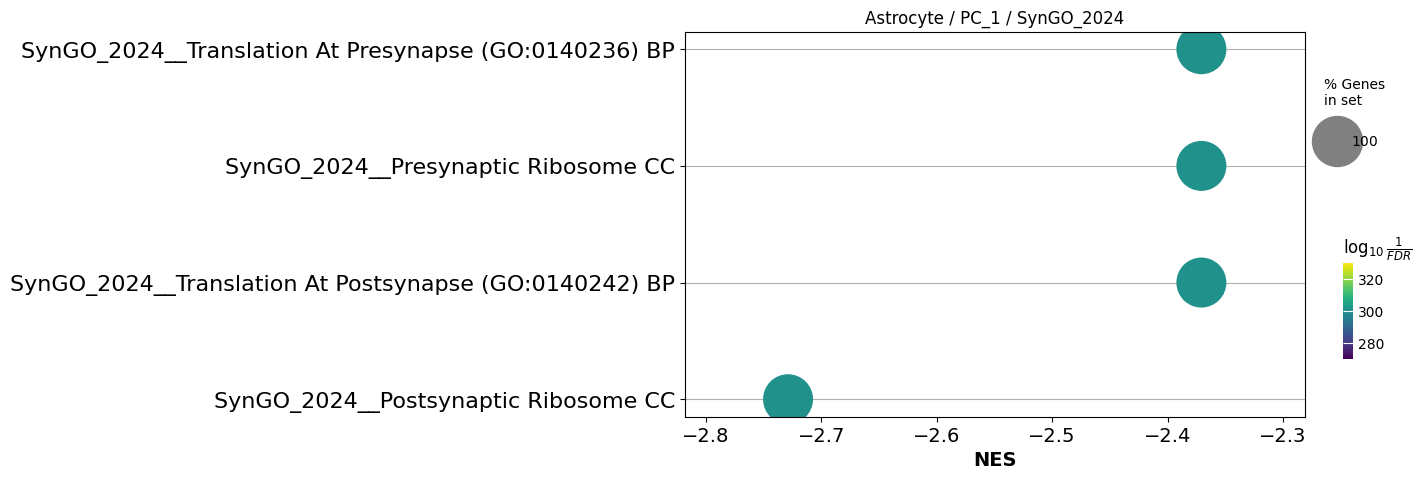

2026-04-15 18:05:47,198 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  30 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Selenocysteine Synthesis,-2.824886,0.0
18,Reactome_Pathways_2024__rRNA Processing,-2.3799,0.0
17,Reactome_Pathways_2024__Selenoamino Acid Metabolism,-2.461021,0.0
16,Reactome_Pathways_2024__Nonsense-Mediated Decay (NMD),-2.497866,0.0
15,Reactome_Pathways_2024__Nonsense Mediated Decay (NMD) Enhanced by the Exon Junction Complex (EJC),-2.497866,0.0
13,Reactome_Pathways_2024__Eukaryotic Translation Elongation,-2.588872,0.0
12,Reactome_Pathways_2024__Peptide Chain Elongation,-2.588872,0.0
11,Reactome_Pathways_2024__Eukaryotic Translation Termination,-2.624208,0.0
10,Reactome_Pathways_2024__Nonsense Mediated Decay (NMD) Independent of the Exon Junction Complex (EJC),-2.624208,0.0
14,Reactome_Pathways_2024__Translation,-2.519333,0.0


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


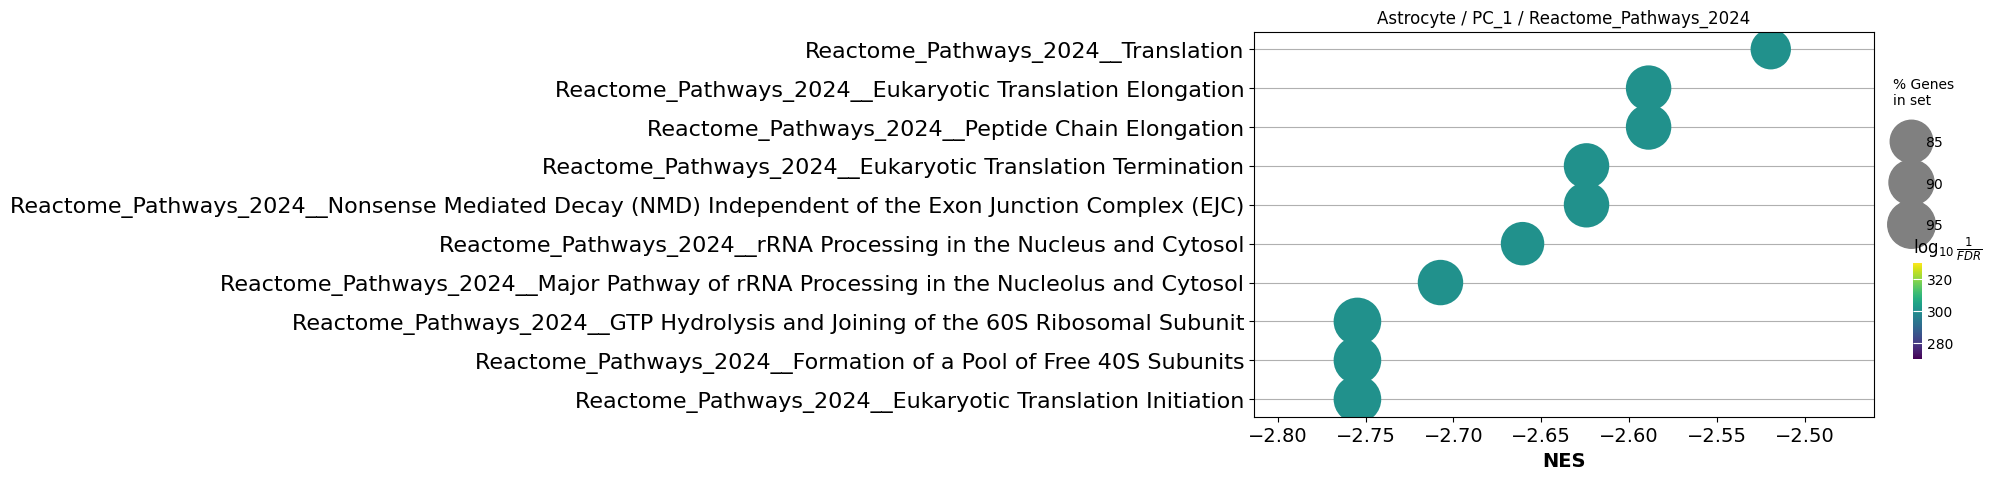

2026-04-15 18:05:49,922 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  10 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),-2.441177,0.0
1,GO_Biological_Process_2025__Ribosome Biogenesis (GO:0042254),-2.355322,0.000809
2,GO_Biological_Process_2025__Ribonucleoprotein Complex Biogenesis (GO:0022613),-2.309799,0.000809
3,GO_Biological_Process_2025__Ribosomal Small Subunit Biogenesis (GO:0042274),-2.245099,0.001819
5,GO_Biological_Process_2025__Translation (GO:0006412),-2.159153,0.004852
4,GO_Biological_Process_2025__rRNA Processing (GO:0006364),-2.164136,0.005013
6,GO_Biological_Process_2025__Chemical Synaptic Transmission (GO:0007268),-2.122494,0.006584
7,GO_Biological_Process_2025__Anterograde Trans-Synaptic Signaling (GO:0098916),-1.966994,0.044372
8,GO_Biological_Process_2025__Positive Regulation of Ossification (GO:0045778),-1.946498,0.045605
9,GO_Biological_Process_2025__Positive Regulation of Biomineral Tissue Development (GO:0070169),-1.946498,0.045605


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


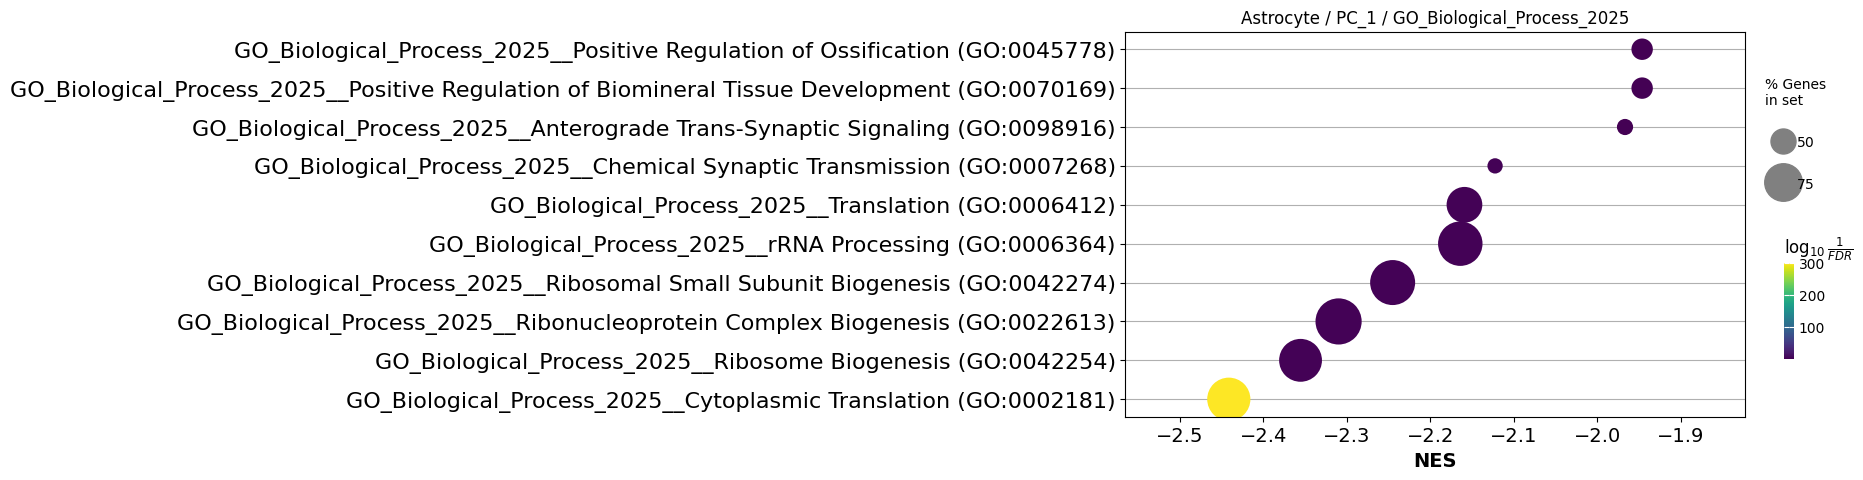

2026-04-15 18:05:53,942 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


2026-04-15 18:05:54,403 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  0 significant (FDR ≤ 0.05)


...


  ──────────────────────────────────────────────────
  FACTOR: PC_2
  ──────────────────────────────────────────────────


gene
CLU             0.088465
CRYAB           0.087133
NEAT1           0.086532
RPLP1           0.085712
FTL             0.084598
                  ...   
LINC00342      -0.056132
PITPNC1        -0.057648
LOC105376244   -0.058745
SLC14A1        -0.066302
XIST           -0.071179
Name: rank_metric, Length: 3000, dtype: float64


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  8 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,PhaseD_genes,2.815136,0.0
2,Gradient_Ventral,-1.793751,0.006008
1,Gradient_DorsalVentral,-1.860525,0.008011
5,Gradient_Dorsal,-1.643819,0.008011
3,PhaseC+_genes,-1.691753,0.010013
4,mix_handsaker,-1.644524,0.010013
7,PhaseC-_genes,-1.459008,0.036716
6,xdp_related,1.47411,0.037725


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


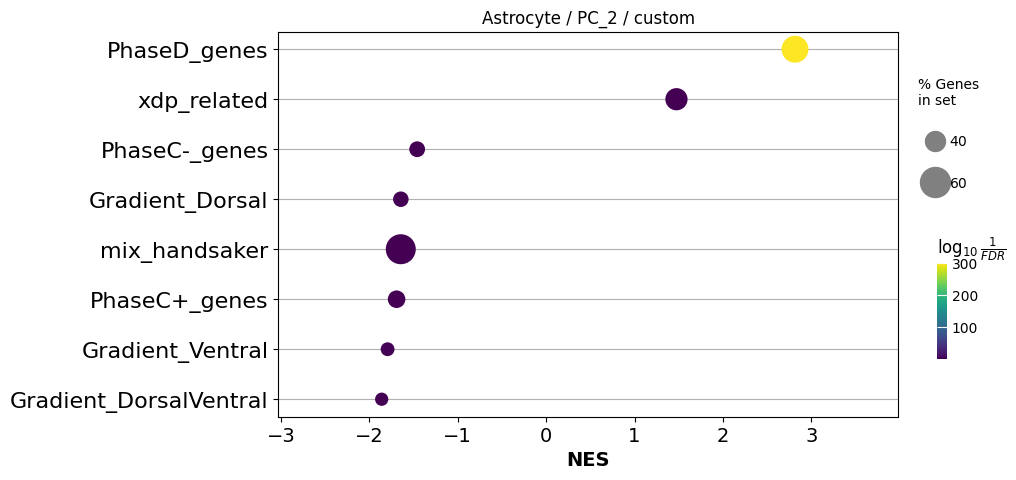


    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  28 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,2.634511,0.0
1,MSigDB_Hallmark_2020__mTORC1 Signaling,2.464769,0.0
2,MSigDB_Hallmark_2020__Hypoxia,2.339873,0.0
3,MSigDB_Hallmark_2020__UV Response Up,2.331725,0.0
4,MSigDB_Hallmark_2020__Apoptosis,2.274467,0.0
5,MSigDB_Hallmark_2020__Unfolded Protein Response,2.172447,0.0
6,MSigDB_Hallmark_2020__Myogenesis,2.126142,0.0
7,MSigDB_Hallmark_2020__Inflammatory Response,2.082109,0.000192
8,MSigDB_Hallmark_2020__Coagulation,2.024208,0.000341
11,MSigDB_Hallmark_2020__p53 Pathway,1.98199,0.000384


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


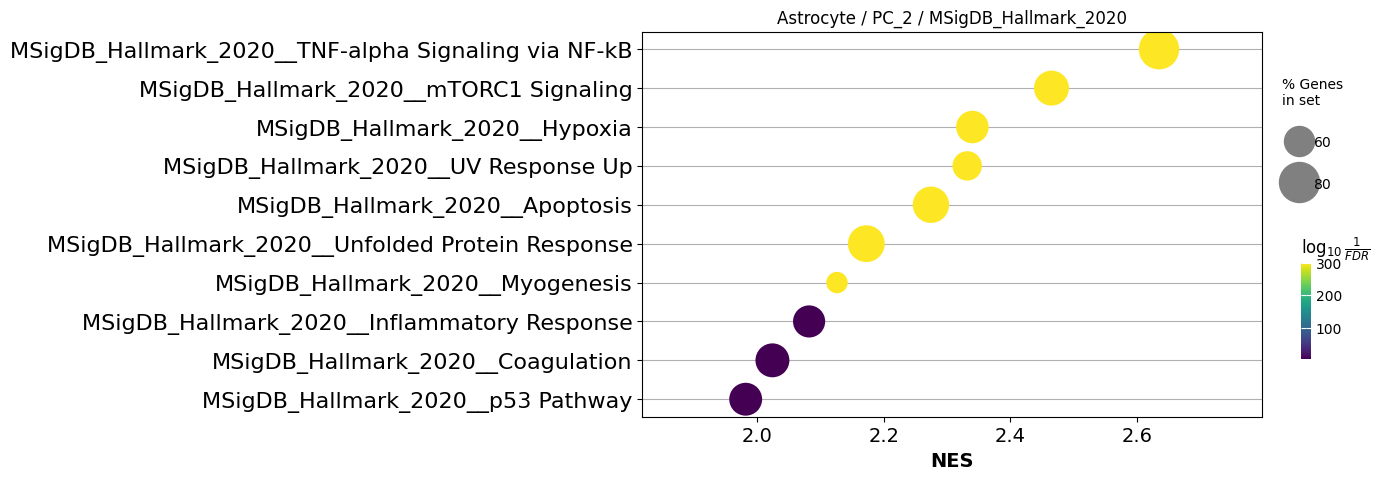


    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  6 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.50469,0.0
1,SynGO_2024__Synapse (GO:0045202) CC,2.475225,0.0
2,SynGO_2024__Presynaptic Ribosome CC,2.238172,0.0
3,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.238172,0.0
4,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.238172,0.0
5,SynGO_2024__Postsynaptic Density (GO:0014069) CC,1.879437,0.00173


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


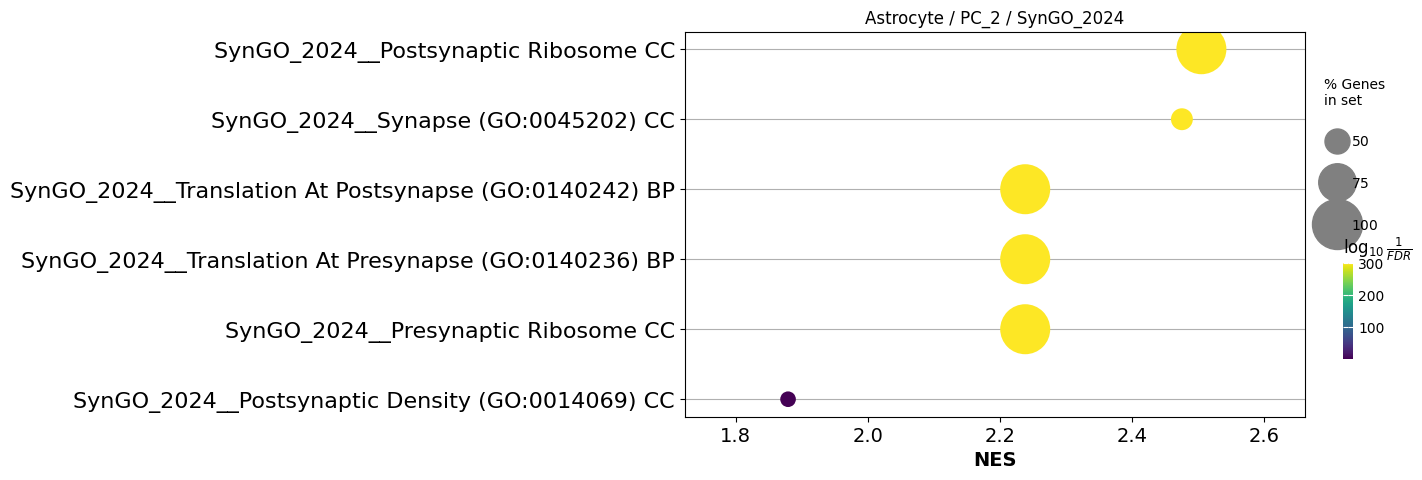


    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  393 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Cellular Responses to Stimuli,2.997254,0.0
29,Reactome_Pathways_2024__Influenza Infection,2.569209,0.0
30,Reactome_Pathways_2024__Influenza Viral RNA Transcription and Replication,2.556346,0.0
31,Reactome_Pathways_2024__Innate Immune System,2.551608,0.0
32,Reactome_Pathways_2024__SARS-CoV Infections,2.518068,0.0
...,...,...,...
403,Reactome_Pathways_2024__Cristae Formation,1.563175,0.048467
405,Reactome_Pathways_2024__Diseases of Signal Transduction by Growth Factor Receptors and Second Messengers,1.561543,0.048916
406,Reactome_Pathways_2024__IRAK2 Mediated Activation of TAK1 Complex,1.558724,0.049818
408,Reactome_Pathways_2024__TRAF6-mediated Induction of TAK1 Complex Within TLR4 Complex,1.558724,0.049818


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


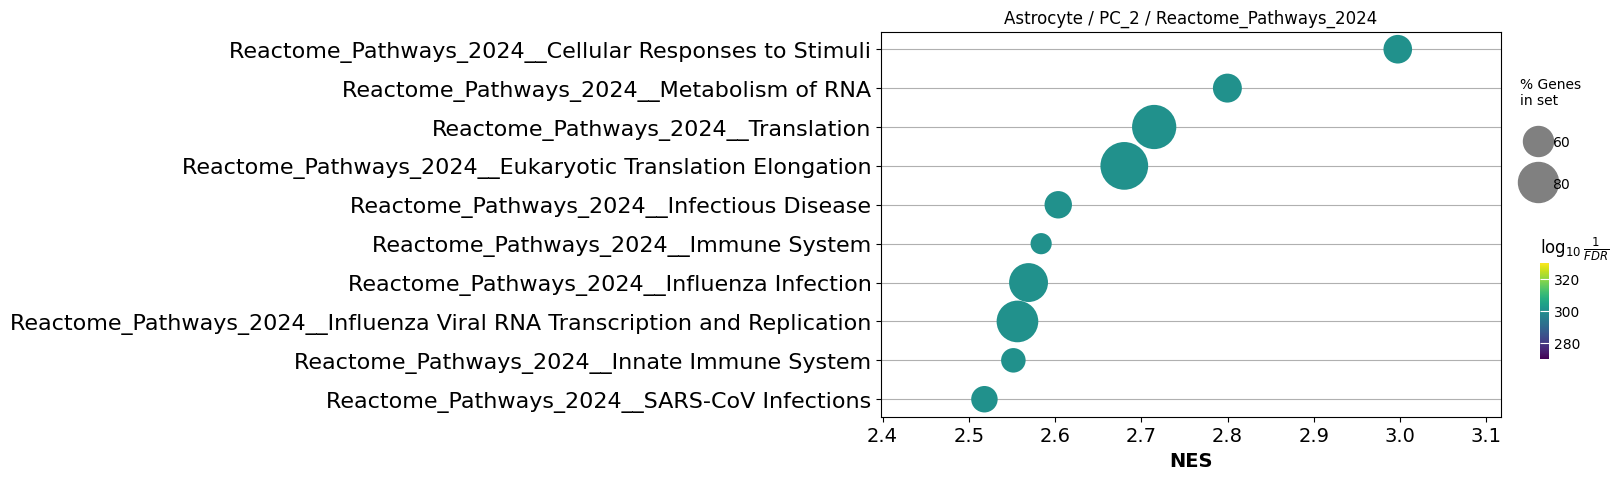


    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  210 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Macromolecule Biosynthetic Process (GO:0009059),2.833149,0.0
26,GO_Biological_Process_2025__Positive Regulation of Intracellular Signal Transduction (GO:1902533),2.161172,0.0
25,GO_Biological_Process_2025__Positive Regulation of Cytokine Production (GO:0001819),2.161712,0.0
24,GO_Biological_Process_2025__Response to Copper Ion (GO:0046688),2.164199,0.0
23,GO_Biological_Process_2025__Cellular Response to Copper Ion (GO:0071280),2.171079,0.0
...,...,...,...
207,GO_Biological_Process_2025__Negative Regulation of Inclusion Body Assembly (GO:0090084),1.664092,0.04838
206,GO_Biological_Process_2025__Negative Regulation of Viral Process (GO:0048525),1.664459,0.048396
210,GO_Biological_Process_2025__Positive Regulation of Cellular Component Biogenesis (GO:0044089),1.662095,0.048937
209,GO_Biological_Process_2025__Positive Regulation of Cell Cycle (GO:0045787),1.662135,0.049144


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


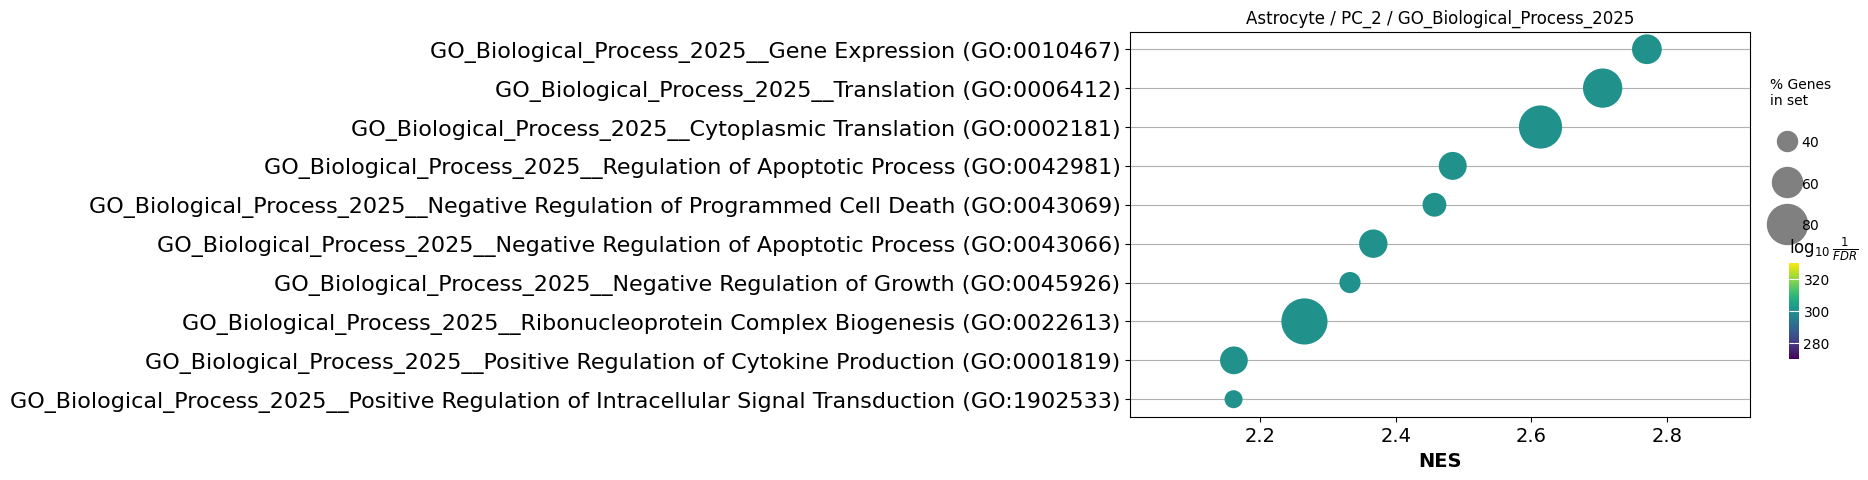


    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  81 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__TAF1 ENCODE,3.097887,0.0
26,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__PPARG CHEA,2.340712,0.0
27,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__USF1 ENCODE,2.339018,0.0
28,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__RELA ENCODE,2.325053,0.0
29,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__UBTF ENCODE,2.287986,0.0
...,...,...,...
76,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__VDR CHEA,1.571139,0.015123
77,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__ERG CHEA,1.565046,0.015967
78,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__GATA2 CHEA,1.544588,0.018587
79,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__IRF8 CHEA,1.48056,0.032094


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


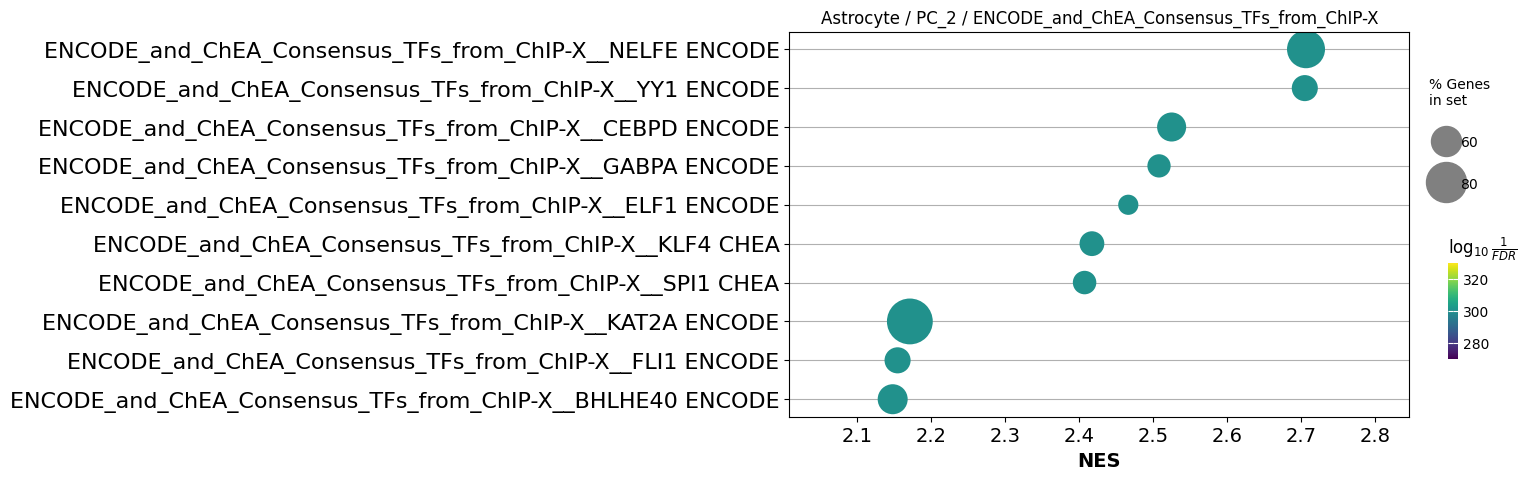


    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  34 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,TRRUST_Transcription_Factors_2019__NFKB1 human,2.2097,0.0
1,TRRUST_Transcription_Factors_2019__TRP53 mouse,2.157511,0.0
2,TRRUST_Transcription_Factors_2019__SP1 human,2.116725,0.0
3,TRRUST_Transcription_Factors_2019__RELA human,2.10294,0.0
8,TRRUST_Transcription_Factors_2019__CEBPB mouse,1.939699,0.00099
7,TRRUST_Transcription_Factors_2019__ATF4 human,1.93989,0.001114
5,TRRUST_Transcription_Factors_2019__SP1 mouse,1.966473,0.001188
6,TRRUST_Transcription_Factors_2019__JUN human,1.942693,0.001273
4,TRRUST_Transcription_Factors_2019__NFKB1 mouse,1.978058,0.001425
9,TRRUST_Transcription_Factors_2019__STAT1 human,1.921086,0.001782


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


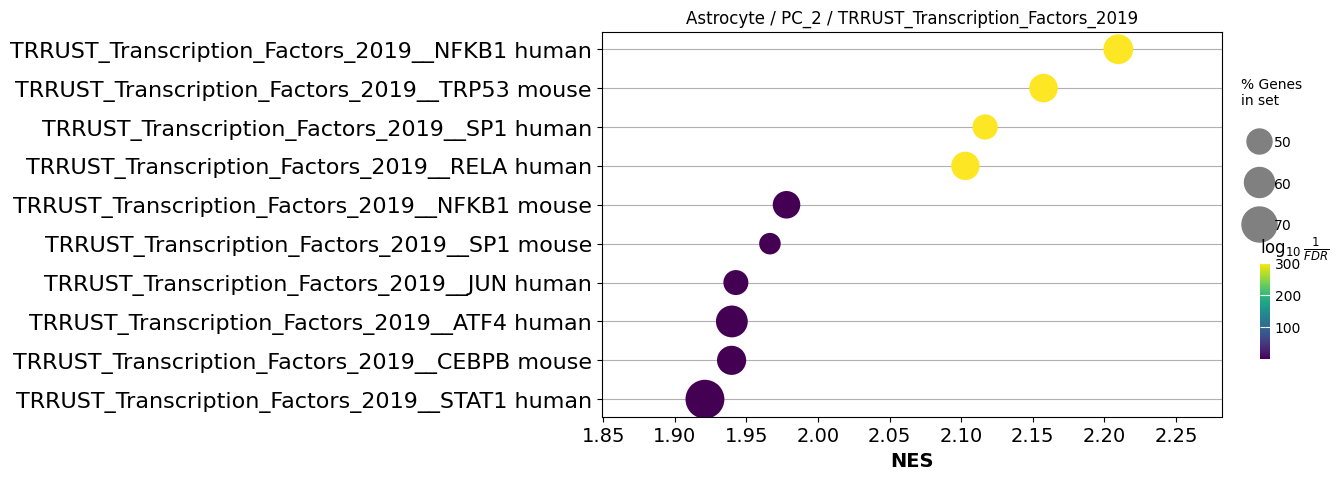

,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
2,PC_2,Astrocyte_WM,3,1.90,4.73,0.953,0.0005,"GFAP, CRYAB, VIM"
9,PC_2,General_Housekeeping,2,2.23,2.23,0.978,0.0010,"GAPDH, B2M"
13,PC_2,General_lncRNA,3,2.43,34.18,0.659,0.1794,"MALAT1, NEAT1, XIST"
12,PC_2,General_Stress_HSP,5,3.80,4.66,0.954,0.0000,"HSPA1A, HSPA1B, HSPB1, HSP90AA1, DNAJB1"
14,PC_2,General_ImmediateEarlyGenes,5,4.90,5.60,0.945,0.0000,"FOS, JUN, FOSB, JUNB, EGR1"
7,PC_2,Microglia_DAM,2,6.83,6.83,0.932,0.0093,"CD9, APOE"
5,PC_2,Astrocyte_A2_Antiinflammatory,3,11.07,15.60,0.845,0.0170,"S100A10, EMP1, SPHK1"
11,PC_2,General_Hypoxia,3,12.00,14.94,0.851,0.0150,"VEGFA, LDHA, SLC2A1"
16,PC_2,Astrocyte_Markers,3,12.23,28.61,0.714,0.1052,"GFAP, S100B, SLC1A2"
4,PC_2,Astrocyte_A1_Reactive,3,12.43,12.94,0.871,0.0097,"C3, SERPING1, GBP2"



  ──────────────────────────────────────────────────
  FACTOR: PC_3
  ──────────────────────────────────────────────────


gene
NR4A3      0.109664
FOSB       0.099165
HSPH1      0.096473
NR4A1      0.090958
SIK1       0.088848
             ...   
MT1G      -0.058685
GSN       -0.060420
MT1F      -0.062658
GJA1      -0.072684
RANBP3L   -0.074052
Name: rank_metric, Length: 3000, dtype: float64


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,PhaseD_genes,-1.936988,0.001575


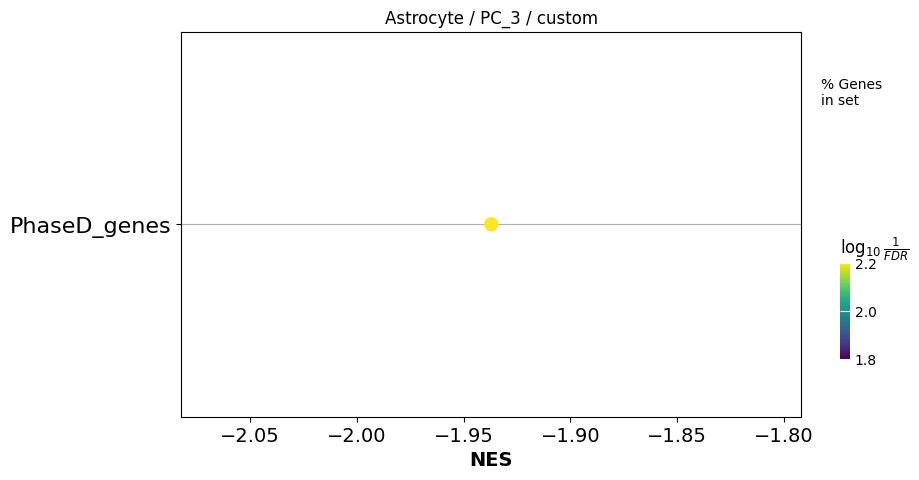


    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  16 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,2.30141,0.0
1,MSigDB_Hallmark_2020__mTORC1 Signaling,2.154683,0.0
3,MSigDB_Hallmark_2020__Unfolded Protein Response,1.886614,0.000626
2,MSigDB_Hallmark_2020__UV Response Up,1.893552,0.000834
5,MSigDB_Hallmark_2020__Fatty Acid Metabolism,1.821884,0.001878
4,MSigDB_Hallmark_2020__Estrogen Response Late,1.826759,0.002003
7,MSigDB_Hallmark_2020__Myc Targets V1,1.786298,0.002347
6,MSigDB_Hallmark_2020__p53 Pathway,1.800176,0.002503
8,MSigDB_Hallmark_2020__Apoptosis,1.773198,0.002782
9,MSigDB_Hallmark_2020__Estrogen Response Early,1.747499,0.004631


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


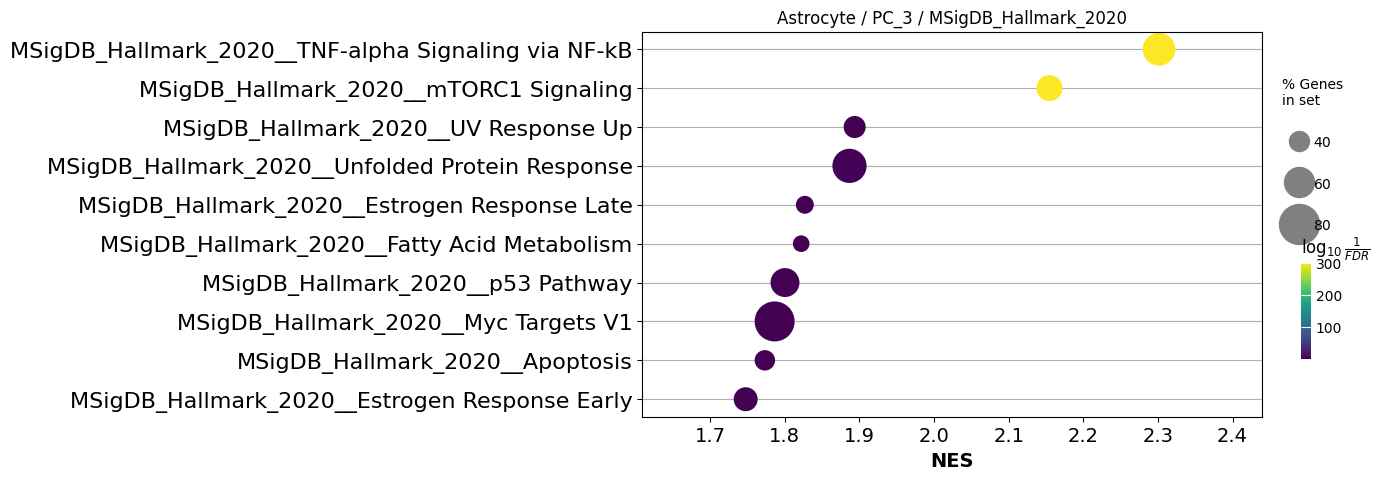


    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  5 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,-2.706355,0.0
1,SynGO_2024__Translation At Presynapse (GO:0140236) BP,-2.322124,0.0
2,SynGO_2024__Presynaptic Ribosome CC,-2.322124,0.0
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,-2.322124,0.0
4,SynGO_2024__Synapse (GO:0045202) CC,-2.215806,0.0


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


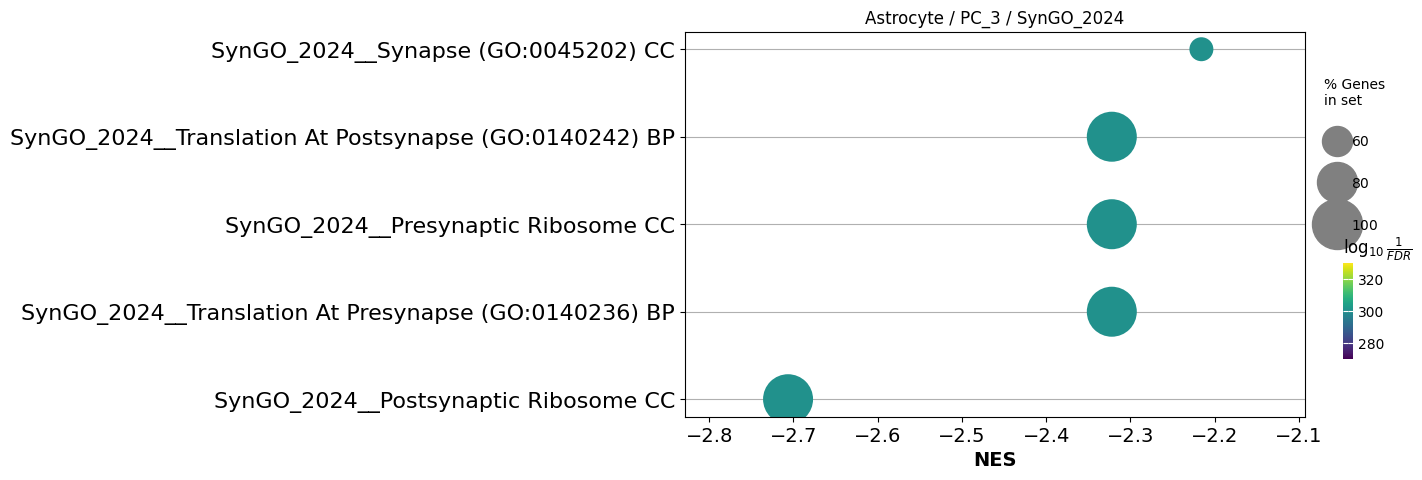


    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  68 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__rRNA Processing in the Nucleus and Cytosol,-2.869581,0.0
20,Reactome_Pathways_2024__Regulation of Expression of SLITs and ROBOs,-2.484617,0.0
21,Reactome_Pathways_2024__Influenza Infection,-2.476696,0.0
22,Reactome_Pathways_2024__Signaling by ROBO Receptors,-2.445762,0.0
23,Reactome_Pathways_2024__Cellular Response to Starvation,-2.4297,0.0
...,...,...,...
63,Reactome_Pathways_2024__Nervous System Development,-1.737365,0.021441
64,Reactome_Pathways_2024__IRE1alpha Activates Chaperones,1.735819,0.025125
65,Reactome_Pathways_2024__Complex IV Assembly,-1.711445,0.029283
67,Reactome_Pathways_2024__SARS-CoV-2-host Interactions,-1.683775,0.040684


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


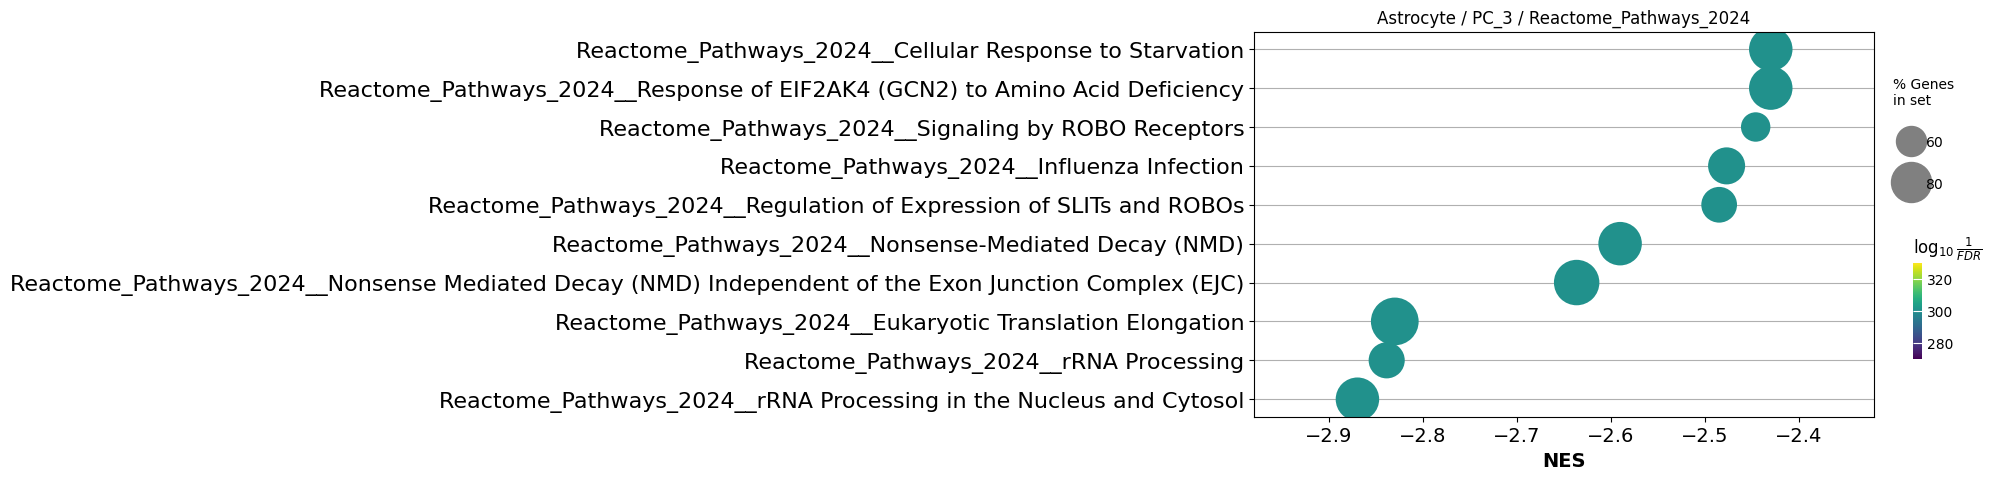


    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  85 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Macromolecule Biosynthetic Process (GO:0009059),-3.000173,0.0
22,GO_Biological_Process_2025__Regulation of DNA-templated Transcription (GO:0006355),2.056358,0.0
20,GO_Biological_Process_2025__Negative Regulation of Transcription by RNA Polymerase II (GO:0000122),2.07306,0.0
19,GO_Biological_Process_2025__Negative Regulation of DNA-templated Transcription (GO:0045892),2.075533,0.0
13,GO_Biological_Process_2025__Gene Expression (GO:0010467),-2.207714,0.0
...,...,...,...
90,GO_Biological_Process_2025__Positive Regulation of miRNA Metabolic Process (GO:2000630),1.671033,0.048887
56,GO_Biological_Process_2025__Regulation of Axon Extension (GO:0030516),-1.746835,0.048989
58,GO_Biological_Process_2025__Outer Dynein Arm Assembly (GO:0036158),-1.743619,0.049311
89,GO_Biological_Process_2025__Insulin Receptor Signaling Pathway (GO:0008286),1.671372,0.049533


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


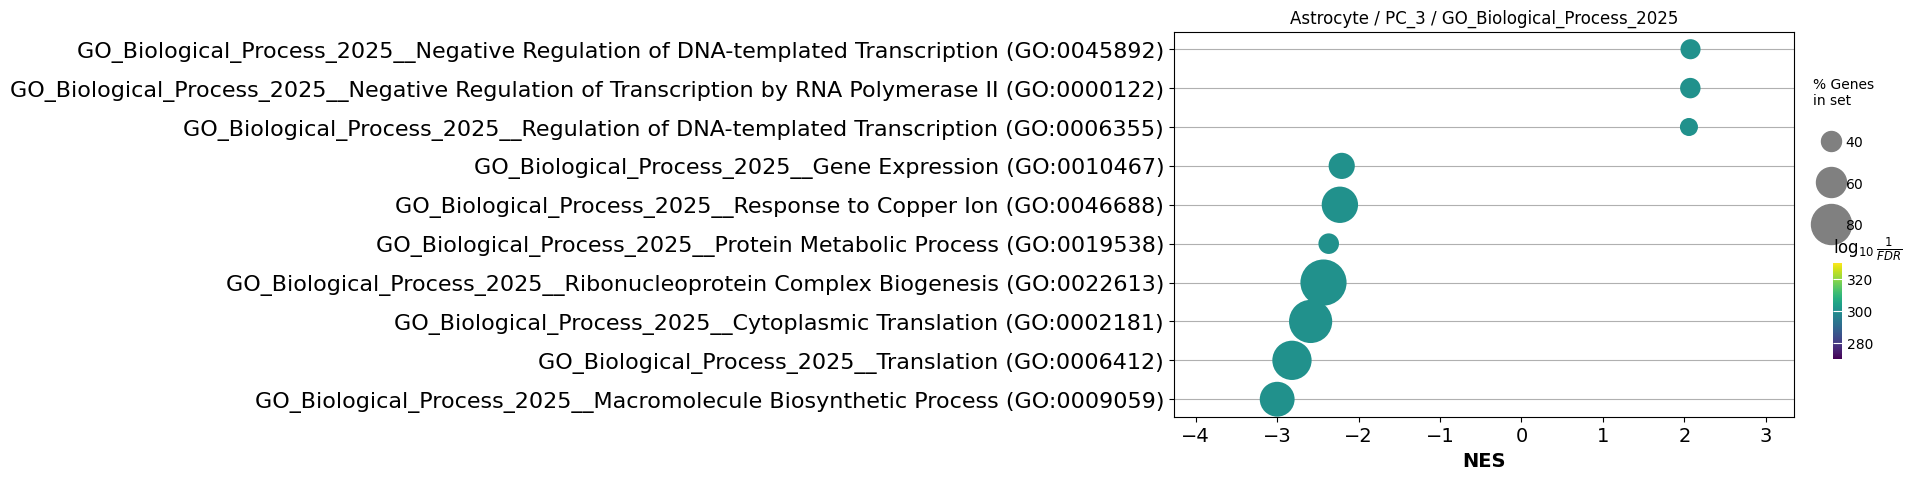


    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  53 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__CREB1 ENCODE,2.378519,0.0
1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__CREB1 CHEA,2.365295,0.0
2,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__NFYA ENCODE,2.13007,0.0
3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__USF1 ENCODE,2.080164,0.0
4,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__BRCA1 ENCODE,2.041382,0.0
12,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__FOS ENCODE,1.908842,0.000091
11,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__IRF3 ENCODE,1.946539,0.000099
10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__PPARG CHEA,1.950001,0.000108
9,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__ATF2 ENCODE,1.9567,0.000119
8,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__BHLHE40 ENCODE,1.966682,0.000132


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


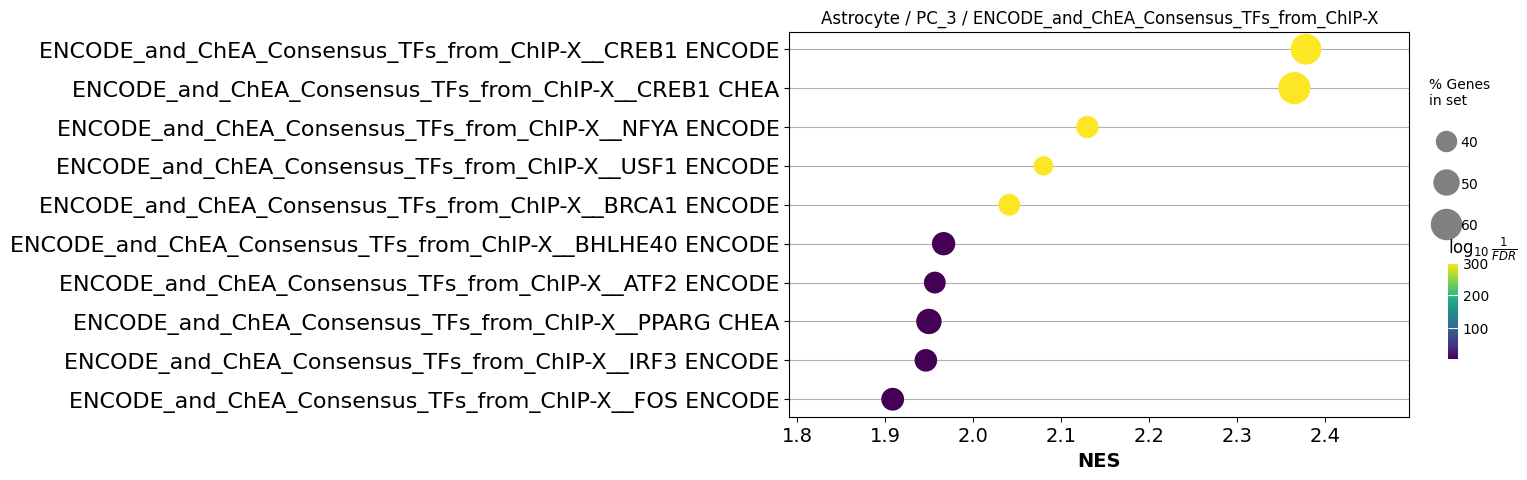


    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  9 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
2,TRRUST_Transcription_Factors_2019__MYC human,1.770663,0.019071
1,TRRUST_Transcription_Factors_2019__SMAD3 human,1.784069,0.021832
3,TRRUST_Transcription_Factors_2019__HSF1 human,1.735833,0.028231
4,TRRUST_Transcription_Factors_2019__JUN mouse,1.720734,0.031016
0,TRRUST_Transcription_Factors_2019__CREB1 human,1.80013,0.033124
7,TRRUST_Transcription_Factors_2019__CLOCK mouse,1.675201,0.045734
6,TRRUST_Transcription_Factors_2019__CLOCK human,1.675201,0.045734
8,TRRUST_Transcription_Factors_2019__ETS1 human,1.668959,0.046006
9,TRRUST_Transcription_Factors_2019__HIF1A human,1.661536,0.047578


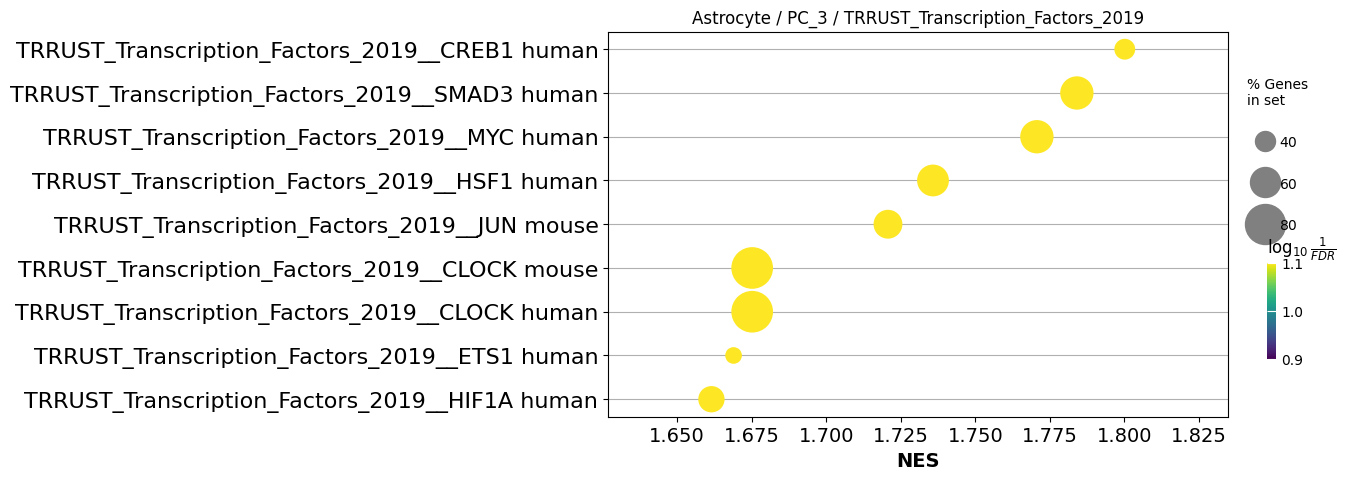

,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
14,PC_3,General_ImmediateEarlyGenes,5,3.00,3.59,0.965,0.0000,"FOS, JUN, FOSB, JUNB, EGR1"
11,PC_3,General_Hypoxia,3,6.60,7.43,0.926,0.0018,"VEGFA, LDHA, SLC2A1"
12,PC_3,General_Stress_HSP,5,9.30,29.15,0.709,0.0537,"HSPA1A, HSPA1B, HSPB1, HSP90AA1, DNAJB1"
3,PC_3,Astrocyte_GM,3,10.80,38.47,0.616,0.2540,"SLC1A2, SLC1A3, GJA1"
15,PC_3,Oligodendrocyte_Markers,2,15.07,15.07,0.850,0.0453,"MBP, PLP1"
10,PC_3,General_Cortisol,3,19.60,29.98,0.701,0.1210,"FKBP5, TSC22D3, PER1"
5,PC_3,Astrocyte_A2_Antiinflammatory,3,32.60,49.10,0.509,0.4795,"S100A10, EMP1, SPHK1"
6,PC_3,Astrocyte_Cortisol,2,44.33,44.33,0.557,0.3929,"FKBP5, TSC22D3"
1,PC_3,Oligodendrocyte_Cortisol,2,44.33,44.33,0.557,0.3929,"FKBP5, TSC22D3"
7,PC_3,Microglia_DAM,2,51.80,51.80,0.482,0.5352,"CD9, APOE"



  ──────────────────────────────────────────────────
  FACTOR: PC_4
  ──────────────────────────────────────────────────


gene
DST         0.097033
TPST1       0.096287
OSMR        0.089825
SERPINA3    0.088597
ITPKC       0.083620
              ...   
C8orf34    -0.054292
DNAH11     -0.055345
MOXD1      -0.055362
WIF1       -0.062153
RMST       -0.066327
Name: rank_metric, Length: 3000, dtype: float64


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  3 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Gradient_Dorsal,-1.748062,0.008598
2,polycomb,1.534742,0.038106
1,PhaseC-_genes,1.579552,0.039194


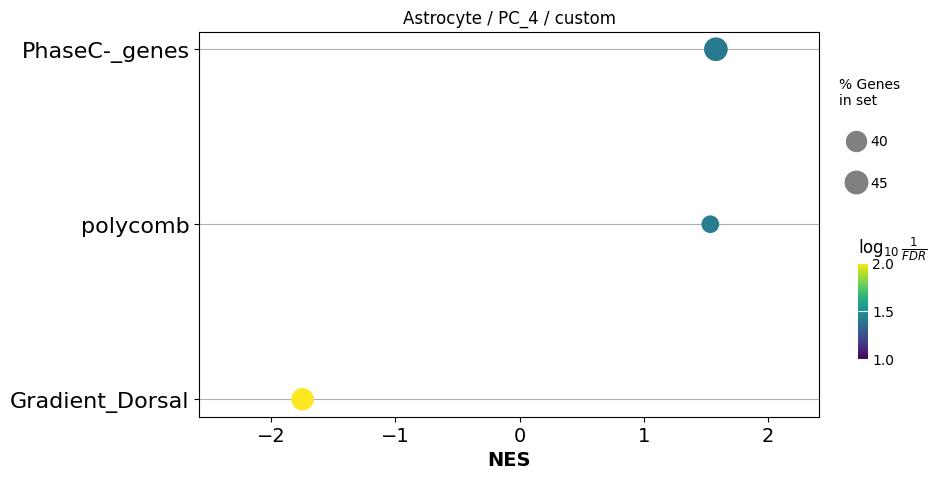


    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  11 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__Interferon Gamma Response,2.203975,0.0
1,MSigDB_Hallmark_2020__Inflammatory Response,2.110463,0.0
2,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,1.894836,0.005856
3,MSigDB_Hallmark_2020__Interferon Alpha Response,1.852957,0.006954
6,MSigDB_Hallmark_2020__Hypoxia,1.787722,0.010876
5,MSigDB_Hallmark_2020__IL-6/JAK/STAT3 Signaling,1.79211,0.011957
4,MSigDB_Hallmark_2020__Reactive Oxygen Species Pathway,1.806382,0.012591
7,MSigDB_Hallmark_2020__Glycolysis,1.733608,0.019582
8,MSigDB_Hallmark_2020__Epithelial Mesenchymal Transition,1.684339,0.03042
9,MSigDB_Hallmark_2020__Complement,1.671219,0.031917


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


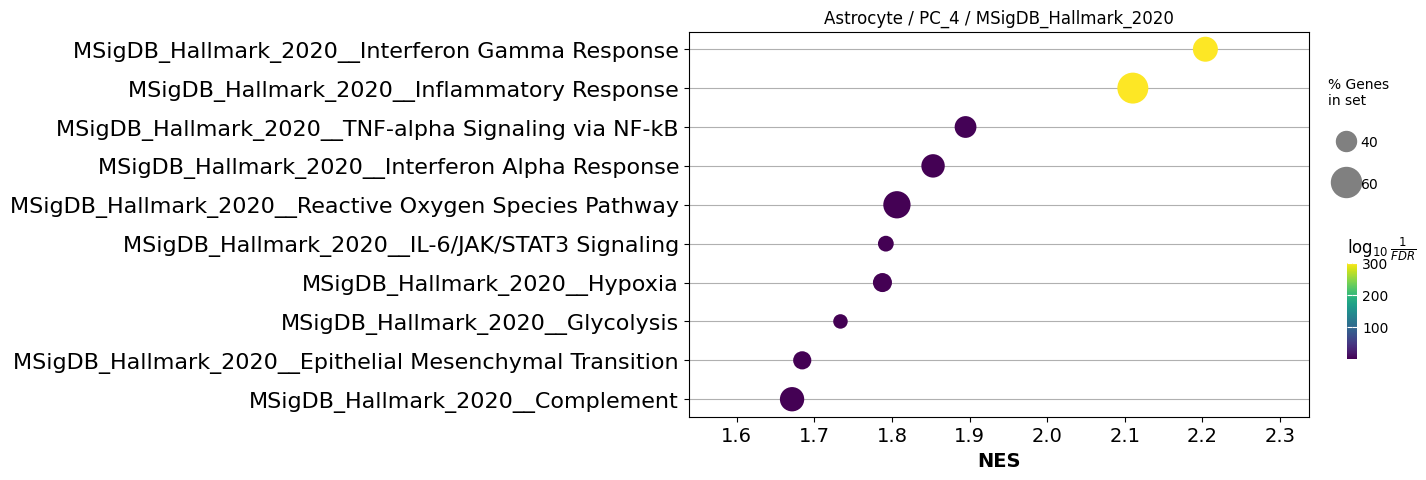


    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  2 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Integral Component Of Presynaptic Active Zone Membrane (GO:0099059) CC,-1.8712,0.012213
1,SynGO_2024__Ligand-Gated IC Activity Involved In Regulation Of Presynaptic Membrane Potential (GO:0099507) BP,-1.768593,0.021373


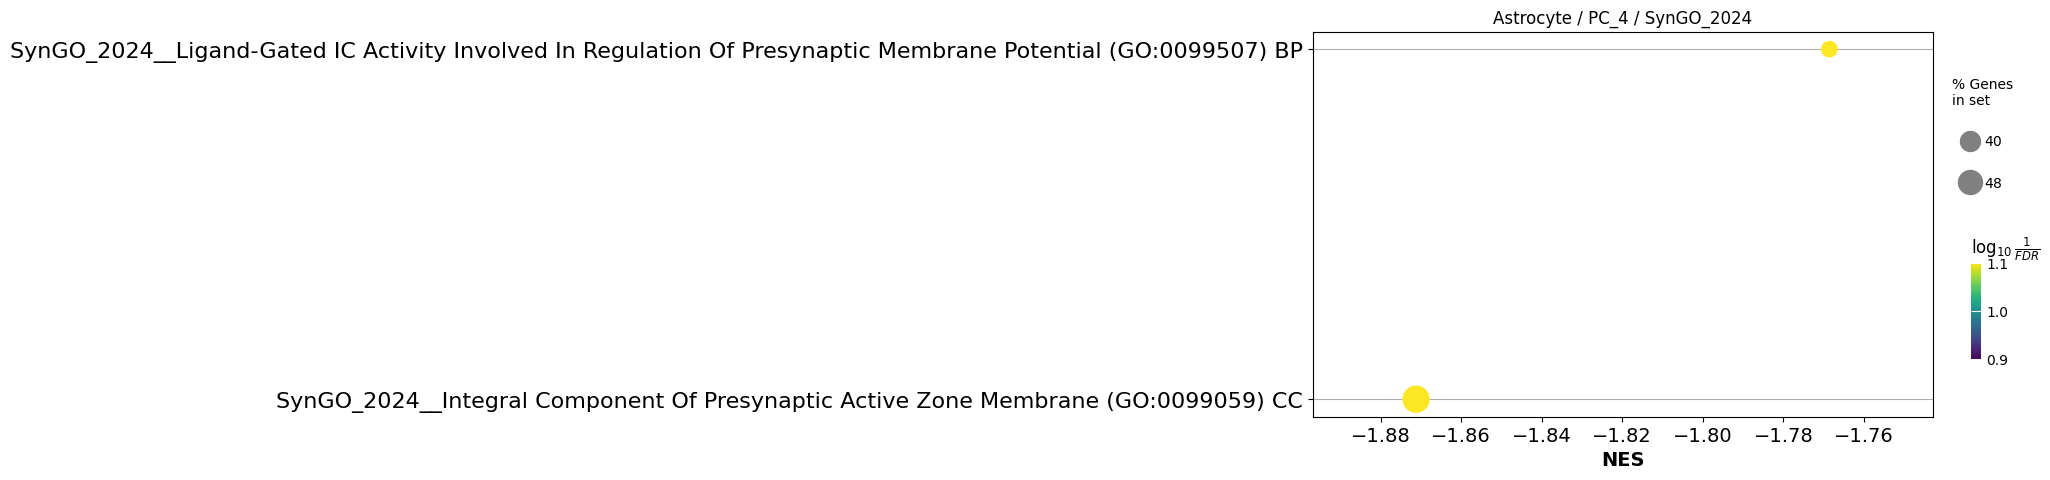


    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  15 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__rRNA Processing in the Mitochondrion,2.114589,0.0
1,Reactome_Pathways_2024__tRNA Processing,2.111827,0.0
2,Reactome_Pathways_2024__tRNA Processing in the Mitochondrion,2.08811,0.0
3,Reactome_Pathways_2024__Mitochondrial RNA Degradation,2.08811,0.0
4,Reactome_Pathways_2024__FASTK Family Proteins Regulate Processing and Stability of Mitochondrial RNAs,2.08811,0.0
5,Reactome_Pathways_2024__rRNA Processing,2.029273,0.002078
6,Reactome_Pathways_2024__Cytokine Signaling in Immune System,1.997806,0.004048
10,Reactome_Pathways_2024__Cell Junction Organization,1.926166,0.005873
9,Reactome_Pathways_2024__Interferon Gamma Signaling,1.932446,0.005894
8,Reactome_Pathways_2024__Respiratory Electron Transport,1.933152,0.006423


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


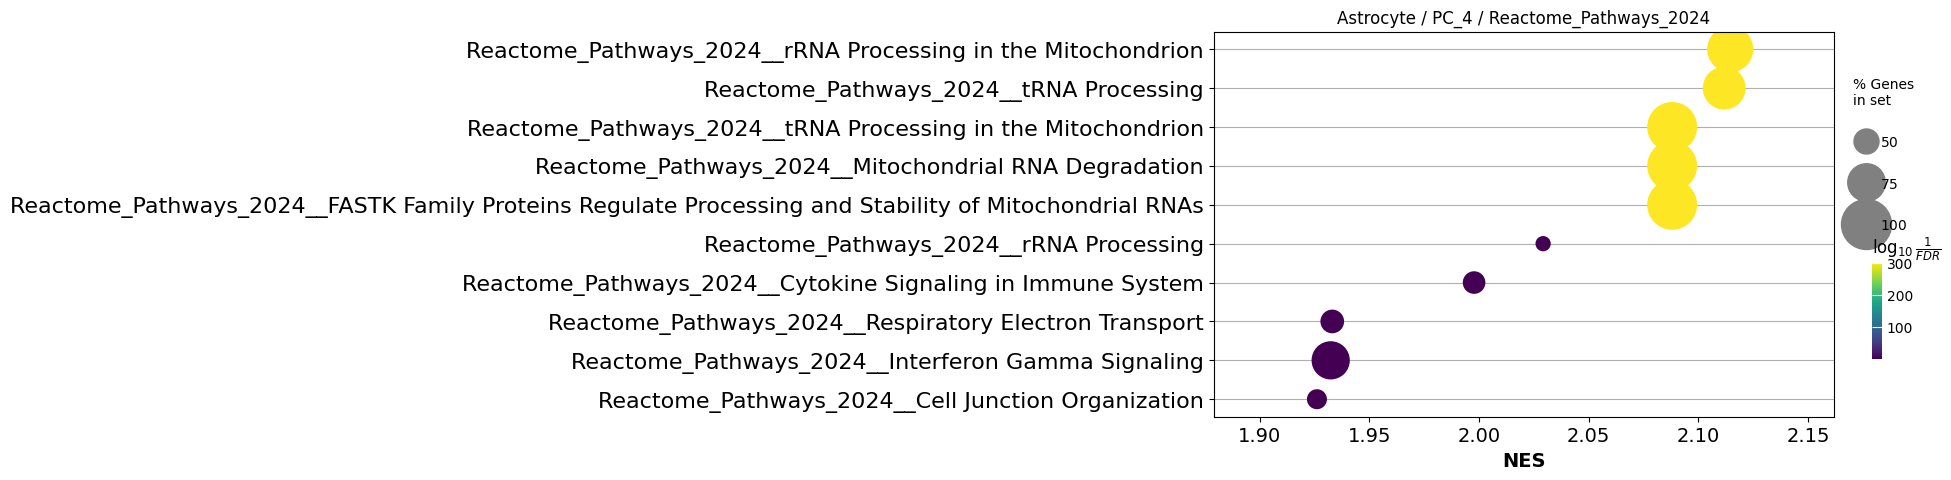


    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  17 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Cilium Movement (GO:0003341),-2.484682,0.0
1,GO_Biological_Process_2025__Cilium Assembly (GO:0060271),-2.143313,0.00046
2,GO_Biological_Process_2025__Axonemal Dynein Complex Assembly (GO:0070286),-2.122965,0.000614
3,GO_Biological_Process_2025__Cilium-Dependent Cell Motility (GO:0060285),-2.07491,0.00115
4,GO_Biological_Process_2025__Cellular Response to Cytokine Stimulus (GO:0071345),2.061436,0.004295
6,GO_Biological_Process_2025__Response to Cytokine (GO:0034097),2.026722,0.004652
5,GO_Biological_Process_2025__Inflammatory Response (GO:0006954),2.037569,0.006442
8,GO_Biological_Process_2025__Cilium Movement Involved in Cell Motility (GO:0060294),-1.920251,0.016383
7,GO_Biological_Process_2025__Defense Response to Virus (GO:0051607),1.94329,0.016641
10,GO_Biological_Process_2025__Determination of Left/Right Symmetry (GO:0007368),-1.897335,0.018539


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


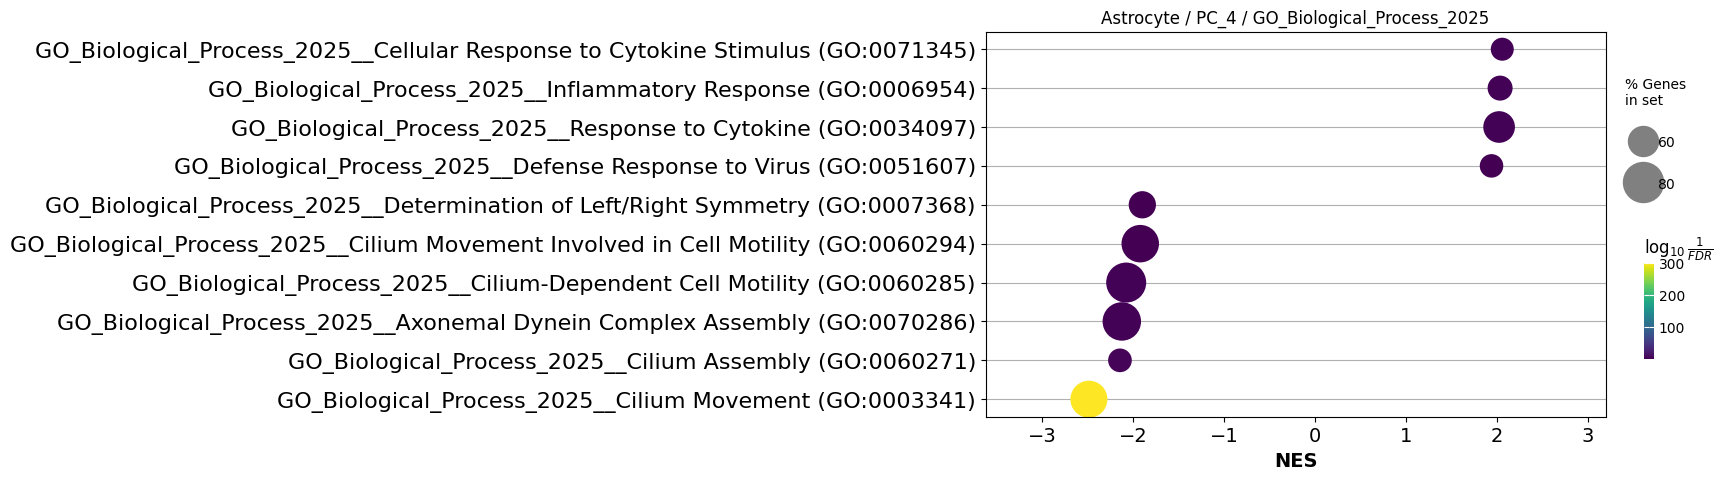


    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  6 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
6,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__CEBPB ENCODE,1.669151,0.042723
9,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__KLF4 CHEA,1.6352,0.043656
7,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__STAT3 CHEA,1.654607,0.043816
8,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__SOX2 CHEA,1.638267,0.047574
2,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__GATA1 CHEA,1.715537,0.04776
14,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__PPARD CHEA,1.584109,0.048533


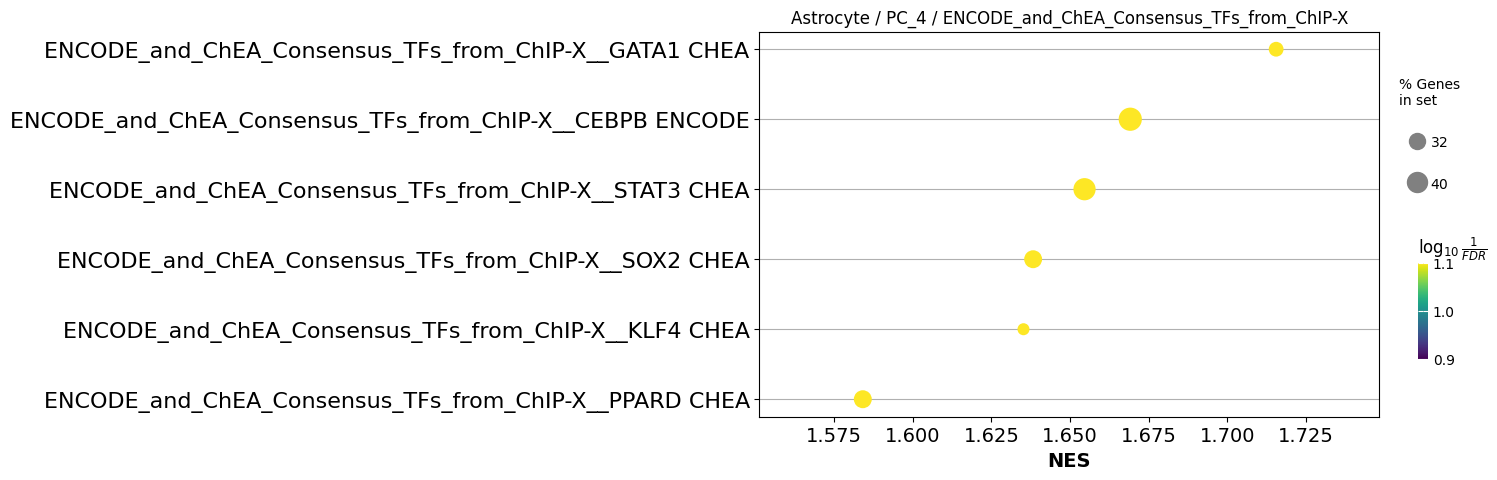


    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  5 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,TRRUST_Transcription_Factors_2019__RELA human,2.297864,0.0
1,TRRUST_Transcription_Factors_2019__NFKB1 human,2.217138,0.0
2,TRRUST_Transcription_Factors_2019__STAT3 human,1.987277,0.000499
3,TRRUST_Transcription_Factors_2019__STAT1 human,1.888283,0.007483
4,TRRUST_Transcription_Factors_2019__IRF1 human,1.827893,0.014068


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


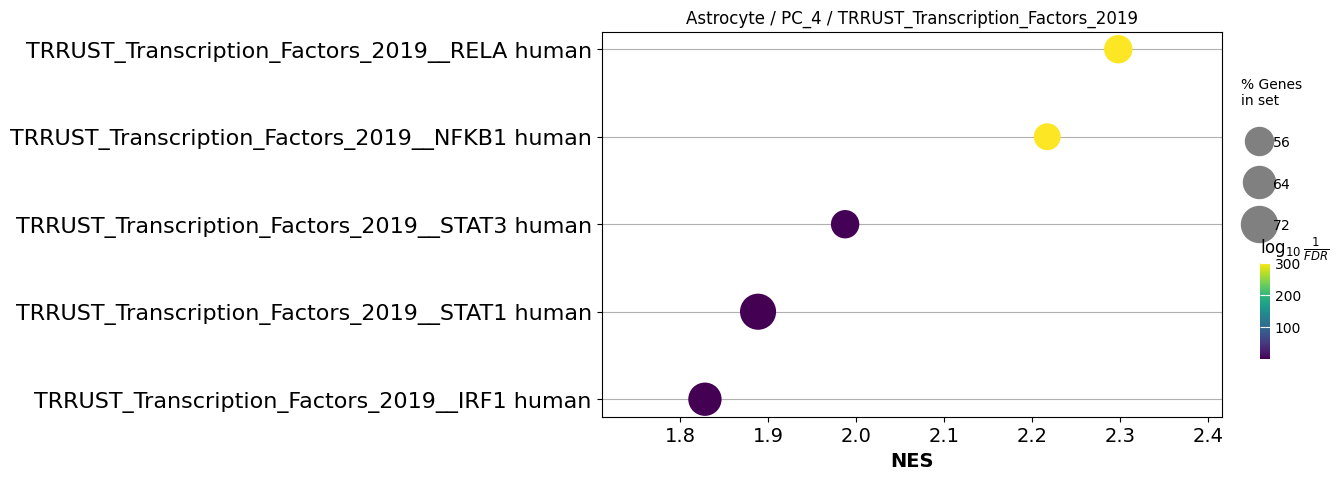

,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
4,PC_4,Astrocyte_A1_Reactive,3,2.13,2.00,0.981,0.0000,"C3, SERPING1, GBP2"
8,PC_4,General_Mito,6,4.83,5.56,0.945,0.0000,"MT-CO1, MT-CO2, MT-ND1, MT-ND3, MT-ATP6, MT-CYB"
13,PC_4,General_lncRNA,3,5.27,4.81,0.953,0.0005,"MALAT1, NEAT1, XIST"
5,PC_4,Astrocyte_A2_Antiinflammatory,3,13.97,11.63,0.884,0.0070,"S100A10, EMP1, SPHK1"
1,PC_4,Oligodendrocyte_Cortisol,2,14.95,14.95,0.851,0.0446,"FKBP5, TSC22D3"
6,PC_4,Astrocyte_Cortisol,2,14.95,14.95,0.851,0.0446,"FKBP5, TSC22D3"
0,PC_4,Oligodendrocyte_Reactive,2,15.02,15.02,0.850,0.0450,"FRY, HSPA1A"
12,PC_4,General_Stress_HSP,5,16.23,15.63,0.844,0.0024,"HSPA1A, HSPA1B, HSPB1, HSP90AA1, DNAJB1"
14,PC_4,General_ImmediateEarlyGenes,5,16.27,42.43,0.576,0.2838,"FOS, JUN, FOSB, JUNB, EGR1"
2,PC_4,Astrocyte_WM,3,25.83,36.89,0.631,0.2250,"GFAP, CRYAB, VIM"



  ──────────────────────────────────────────────────
  FACTOR: PC_5
  ──────────────────────────────────────────────────


gene
F3         0.087914
PLSCR1     0.085359
ACTN1      0.076092
LRRC3B     0.074634
GALNT16    0.073301
             ...   
DAAM2     -0.067038
ADCY1     -0.067312
KCNN3     -0.069130
TRPM3     -0.074027
ACACB     -0.074612
Name: rank_metric, Length: 3000, dtype: float64


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  4 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,PhaseD_genes,-1.741391,0.007338
3,PhaseC+_genes,1.549793,0.029705
2,Gradient_DorsalVentral,1.568102,0.037789
1,Gradient_Dorsal,1.605808,0.047377


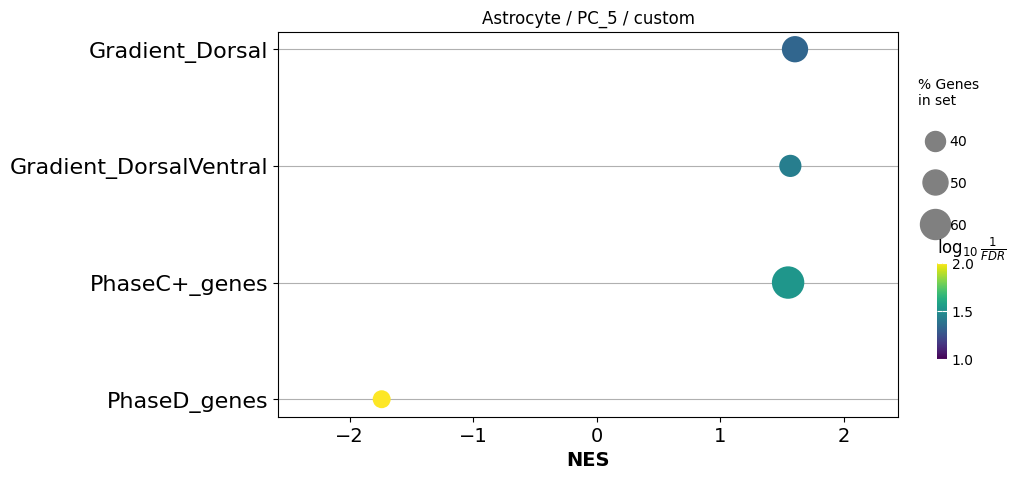


    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__Inflammatory Response,1.949322,0.00401


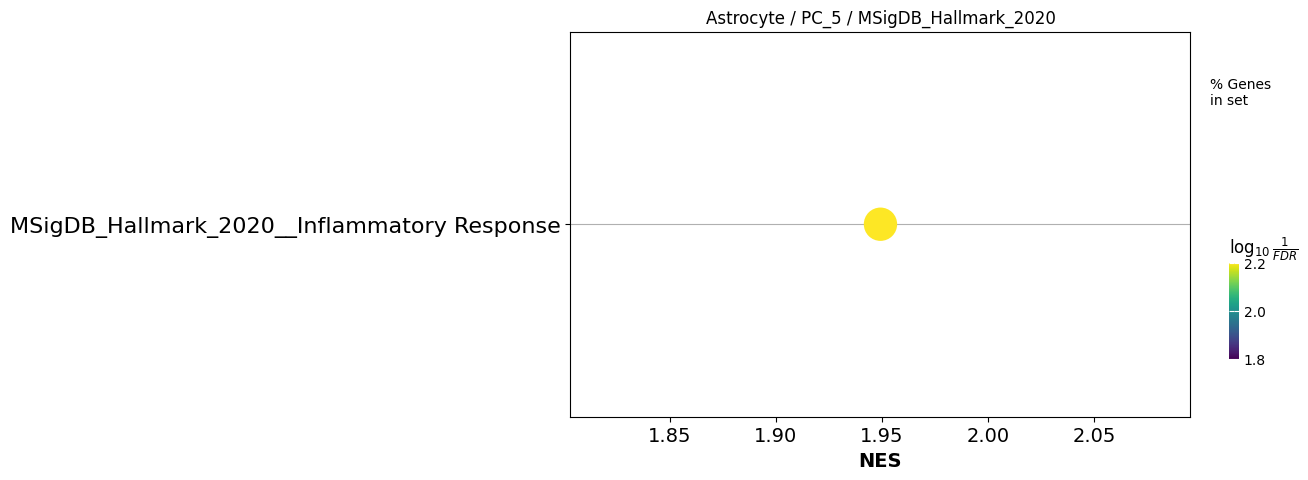


    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  5 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,-2.082096,0.002481
1,SynGO_2024__Translation At Presynapse (GO:0140236) BP,-1.775839,0.020678
2,SynGO_2024__Presynaptic Ribosome CC,-1.775839,0.020678
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,-1.775839,0.020678
4,SynGO_2024__Integral Component Of Postsynaptic Specialization Membrane (GO:0099060) CC,1.743473,0.027484


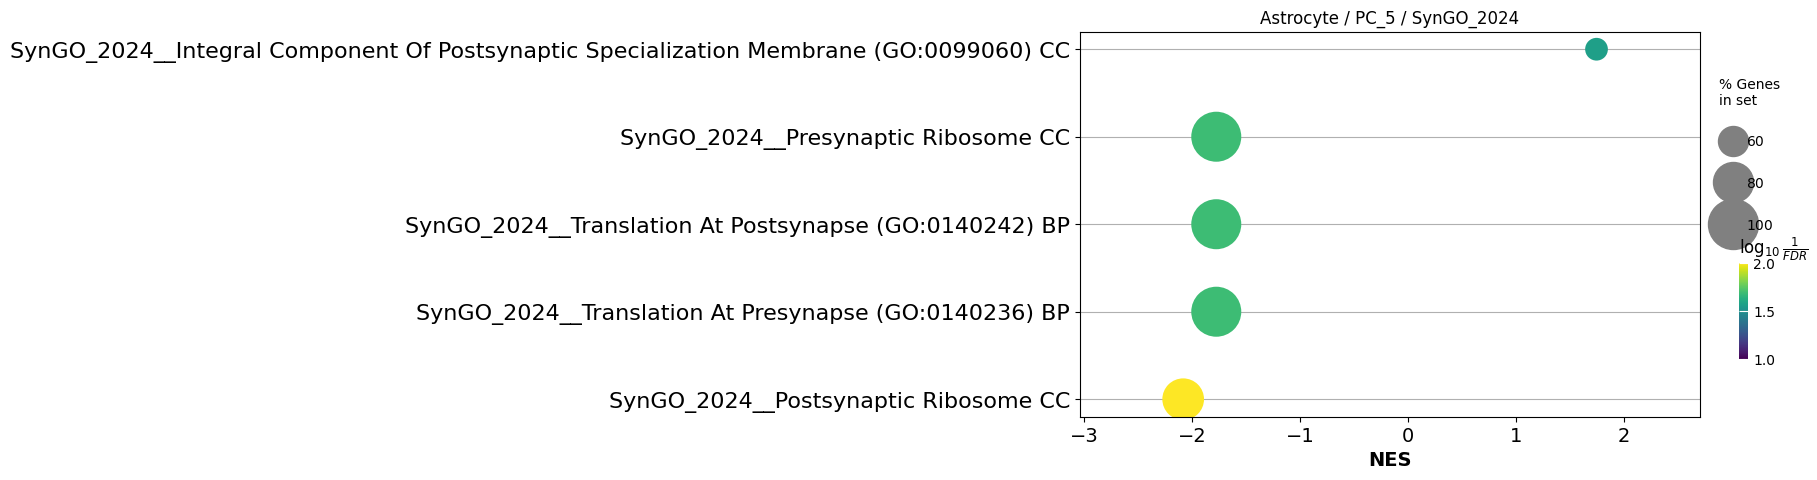


    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  49 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Cellular Response to Heat Stress,-2.499029,0.0
1,Reactome_Pathways_2024__HSF1-dependent Transactivation,-2.482289,0.0
2,Reactome_Pathways_2024__Attenuation Phase,-2.414329,0.0
3,Reactome_Pathways_2024__HSF1 Activation,-2.323932,0.000433
4,Reactome_Pathways_2024__Regulation of HSF1-mediated Heat Shock Response,-2.224605,0.001386
9,Reactome_Pathways_2024__rRNA Processing,-2.133486,0.001732
5,Reactome_Pathways_2024__HSP90 Chaperone Cycle for Steroid Hormone Receptors (SHR) in the Presence of Ligand,-2.173095,0.001732
6,Reactome_Pathways_2024__Influenza Infection,-2.156994,0.001732
10,Reactome_Pathways_2024__Major Pathway of rRNA Processing in the Nucleolus and Cytosol,-2.122944,0.001889
8,Reactome_Pathways_2024__Cellular Response to Starvation,-2.137861,0.001924


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


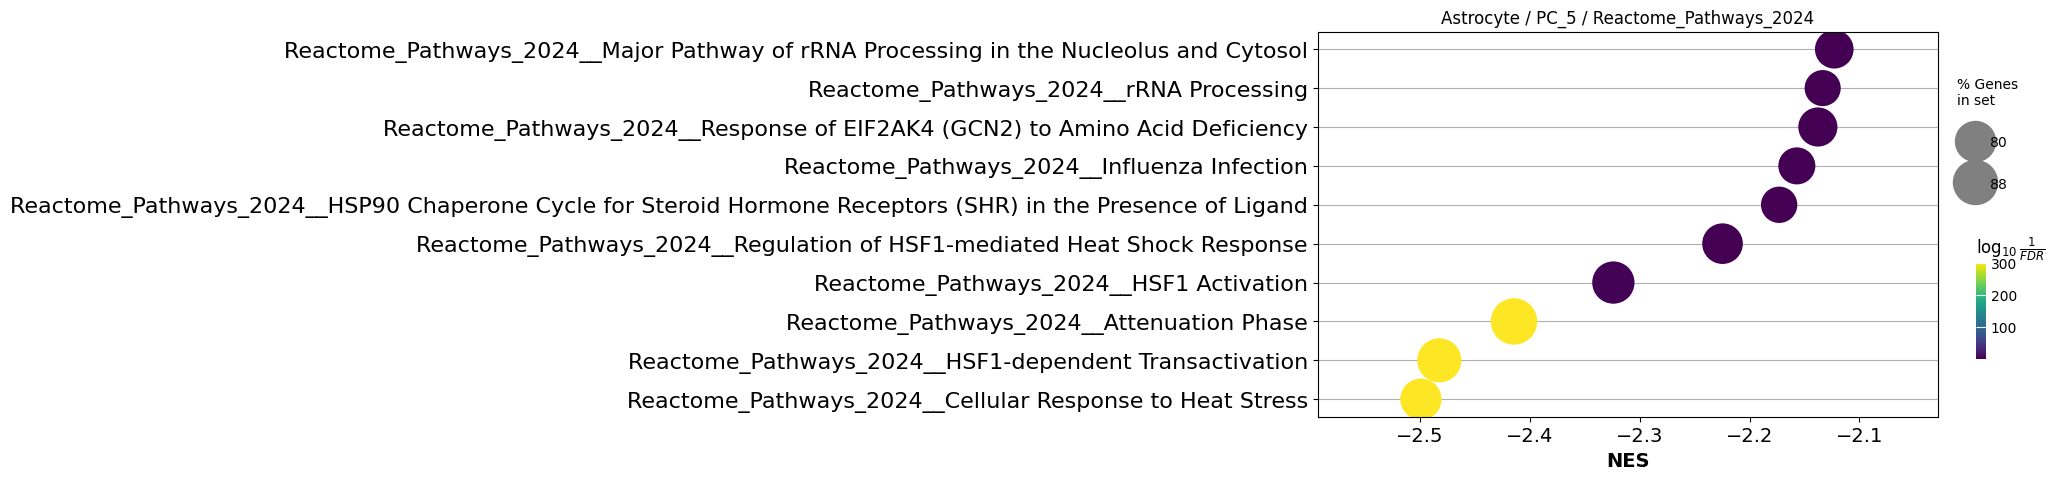


    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  24 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Response to Unfolded Protein (GO:0006986),-2.543698,0.0
1,GO_Biological_Process_2025__Regulation of Protein Ubiquitination (GO:0031396),-2.415835,0.0
2,GO_Biological_Process_2025__Chaperone Cofactor-Dependent Protein Refolding (GO:0051085),-2.203608,0.00042
3,GO_Biological_Process_2025__'De Novo' Post-Translational Protein Folding (GO:0051084),-2.203608,0.00042
4,GO_Biological_Process_2025__Negative Regulation of Protein Modification by Small Protein Conjugation or Removal (GO:1903321),-2.135862,0.004036
5,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),-2.090107,0.007849
9,GO_Biological_Process_2025__Chloride Transport (GO:0006821),2.000605,0.009825
13,GO_Biological_Process_2025__Response to Tumor Necrosis Factor (GO:0034612),1.971448,0.011463
8,GO_Biological_Process_2025__Negative Regulation of Protein Ubiquitination (GO:0031397),-2.033593,0.012053
7,GO_Biological_Process_2025__Cellular Response to Heat (GO:0034605),-2.03705,0.013034


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


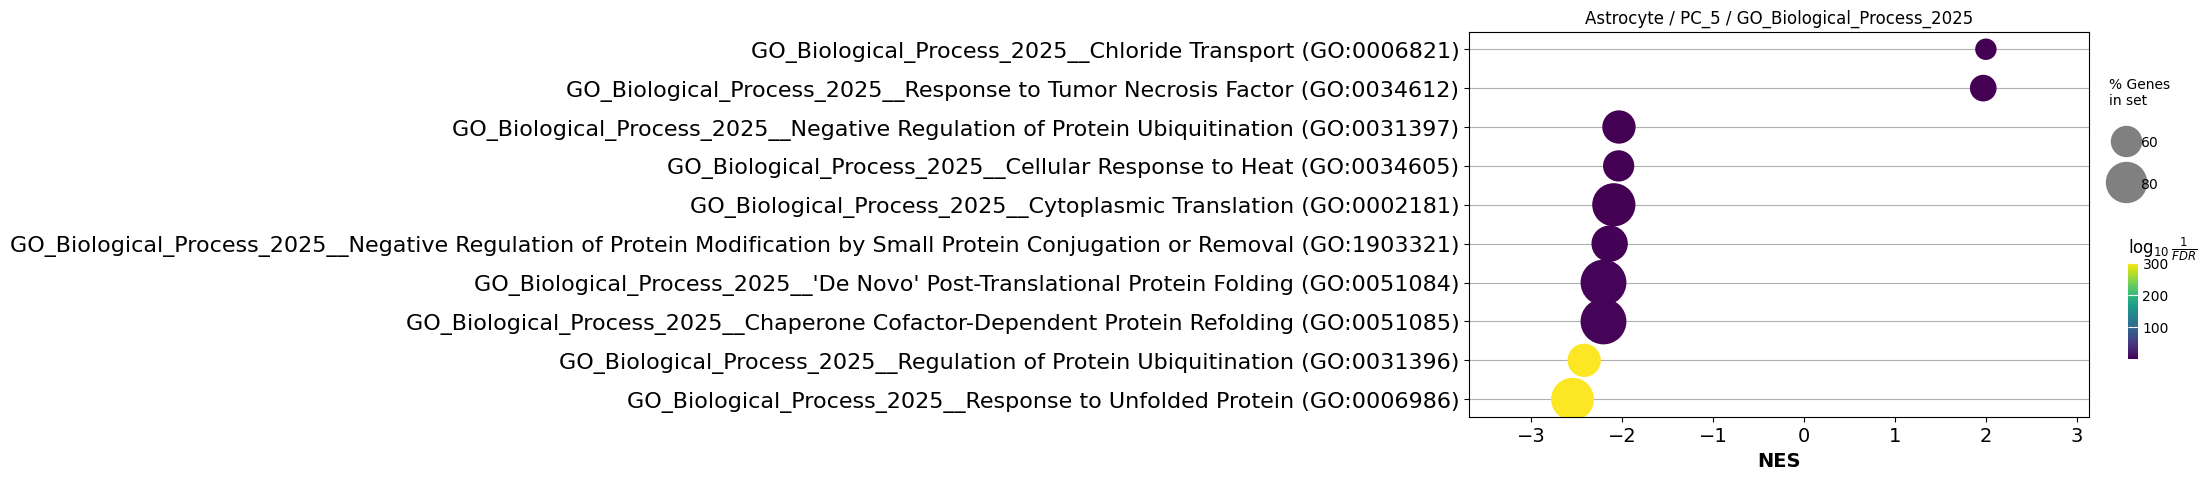


    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  3 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__USF2 ENCODE,-1.976732,0.008349
0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__KAT2A ENCODE,-2.004907,0.011132
2,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__TAF7 ENCODE,-1.877927,0.018554


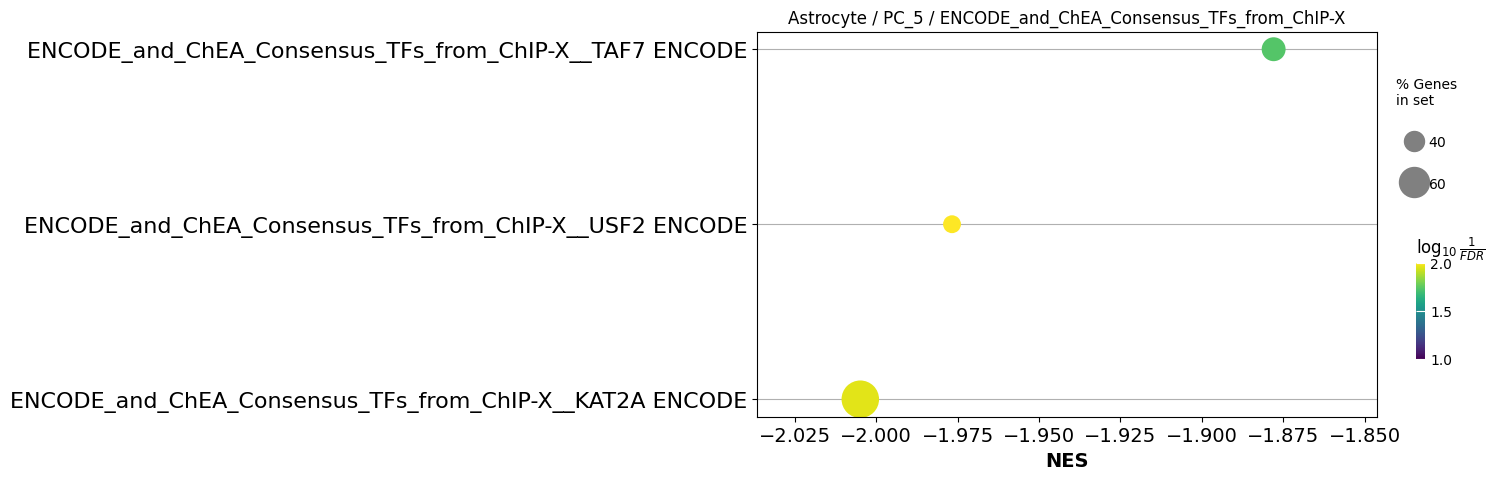


    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


    [plot]   Skipping dotplot — no significant terms


,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
4,PC_5,Astrocyte_A1_Reactive,3,3.03,15.18,0.849,0.0157,"C3, SERPING1, GBP2"
3,PC_5,Astrocyte_GM,3,8.13,29.70,0.703,0.1177,"SLC1A2, SLC1A3, GJA1"
5,PC_5,Astrocyte_A2_Antiinflammatory,3,34.77,36.66,0.634,0.2209,"S100A10, EMP1, SPHK1"
9,PC_5,General_Housekeeping,2,36.50,36.50,0.635,0.2663,"GAPDH, B2M"
11,PC_5,General_Hypoxia,3,43.30,58.01,0.420,0.6754,"VEGFA, LDHA, SLC2A1"
7,PC_5,Microglia_DAM,2,58.53,58.53,0.415,0.6560,"CD9, APOE"
16,PC_5,Astrocyte_Markers,3,66.03,52.23,0.478,0.5499,"GFAP, S100B, SLC1A2"
0,PC_5,Oligodendrocyte_Reactive,2,66.87,66.87,0.331,0.7804,"FRY, HSPA1A"
8,PC_5,General_Mito,6,79.57,74.26,0.257,0.9814,"MT-CO1, MT-CO2, MT-ND1, MT-ND3, MT-ATP6, MT-CYB"
15,PC_5,Oligodendrocyte_Markers,2,81.63,81.63,0.184,0.9325,"MBP, PLP1"



  ──────────────────────────────────────────────────
  FACTOR: PC_6
  ──────────────────────────────────────────────────


gene
STK32A    0.093616
PDZD2     0.081855
TRPM3     0.074475
FAT3      0.073730
LAMA2     0.072466
            ...   
TENM4    -0.048455
PFKFB3   -0.055769
AHNAK    -0.056300
MMD2     -0.060499
DPP10    -0.071514
Name: rank_metric, Length: 3000, dtype: float64


    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  6 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
1,PhaseC+_genes,1.770744,0.00049
0,PhaseC-_genes,1.864517,0.00098
2,PhaseD_genes,1.637339,0.003265
3,Gradient_Ventral,1.606562,0.003428
4,Gradient_DorsalVentral,1.561819,0.005877
5,Gradient_Dorsal,1.377766,0.044243


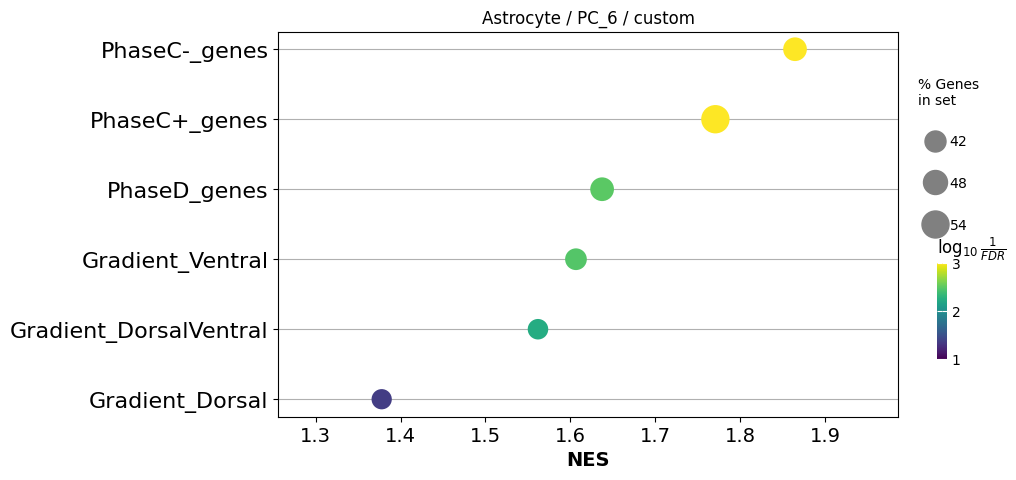


    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  10 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.086879,0.0
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.875417,0.000239
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,1.875417,0.000239
4,SynGO_2024__Presynaptic Ribosome CC,1.875417,0.000239
5,SynGO_2024__Postsynaptic Density (GO:0014069) CC,1.842334,0.000399
1,SynGO_2024__Synapse (GO:0045202) CC,1.883766,0.000598
6,SynGO_2024__Integral Component Of Postsynaptic Density Membrane (GO:0099061) CC,1.614176,0.030943
7,SynGO_2024__Anchored Component Of Presynaptic Membrane (GO:0099026) CC,1.600229,0.033806
9,SynGO_2024__Presynapse (GO:0098793) CC,1.569078,0.041046
8,SynGO_2024__Presynaptic Membrane (GO:0042734) CC,1.570136,0.044809


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


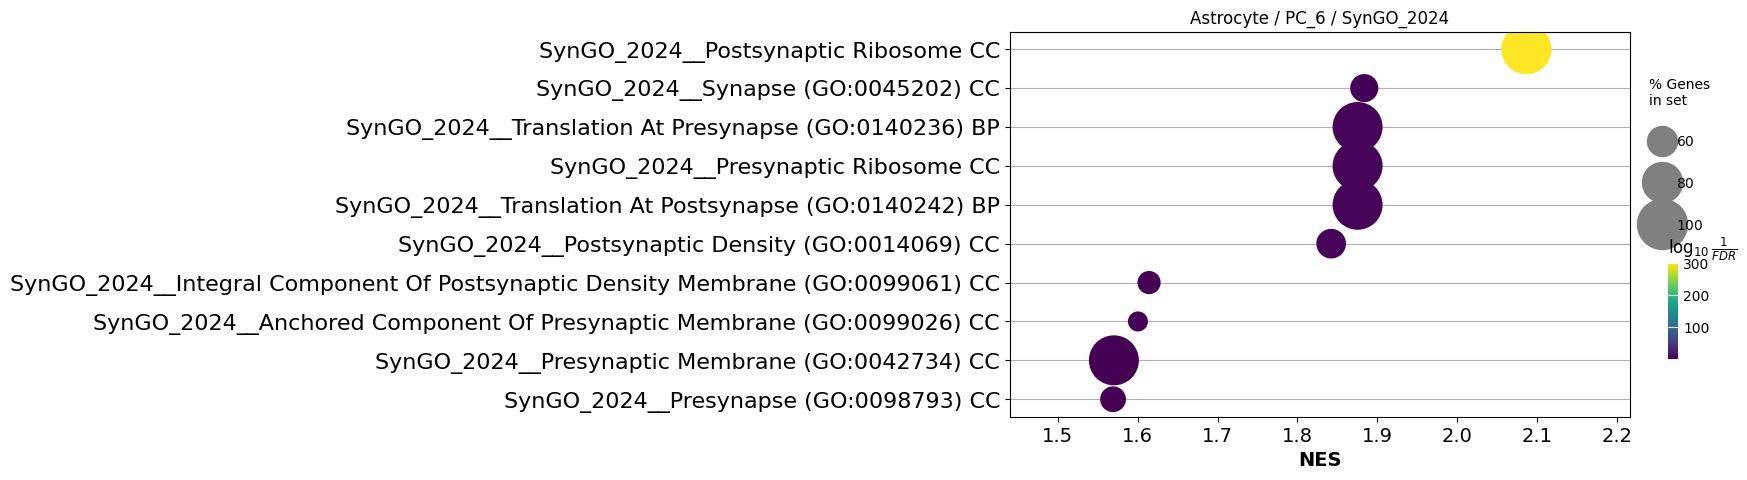


    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  85 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
24,Reactome_Pathways_2024__Selenoamino Acid Metabolism,2.089169,0.0
32,Reactome_Pathways_2024__SARS-CoV-2-host Interactions,1.951221,0.0
31,Reactome_Pathways_2024__Aerobic Respiration and Respiratory Electron Transport,1.973525,0.0
30,Reactome_Pathways_2024__SARS-CoV-1-host Interactions,1.98869,0.0
29,Reactome_Pathways_2024__Cellular Responses to Stress,2.003354,0.0
...,...,...,...
87,Reactome_Pathways_2024__Mitotic Spindle Checkpoint,1.642775,0.029929
90,Reactome_Pathways_2024__Signaling by CSF1 (M-CSF) in Myeloid Cells,1.617302,0.044928
89,Reactome_Pathways_2024__Transmission Across Chemical Synapses,1.617513,0.045372
33,Reactome_Pathways_2024__O-linked Glycosylation,-1.945338,0.047564


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


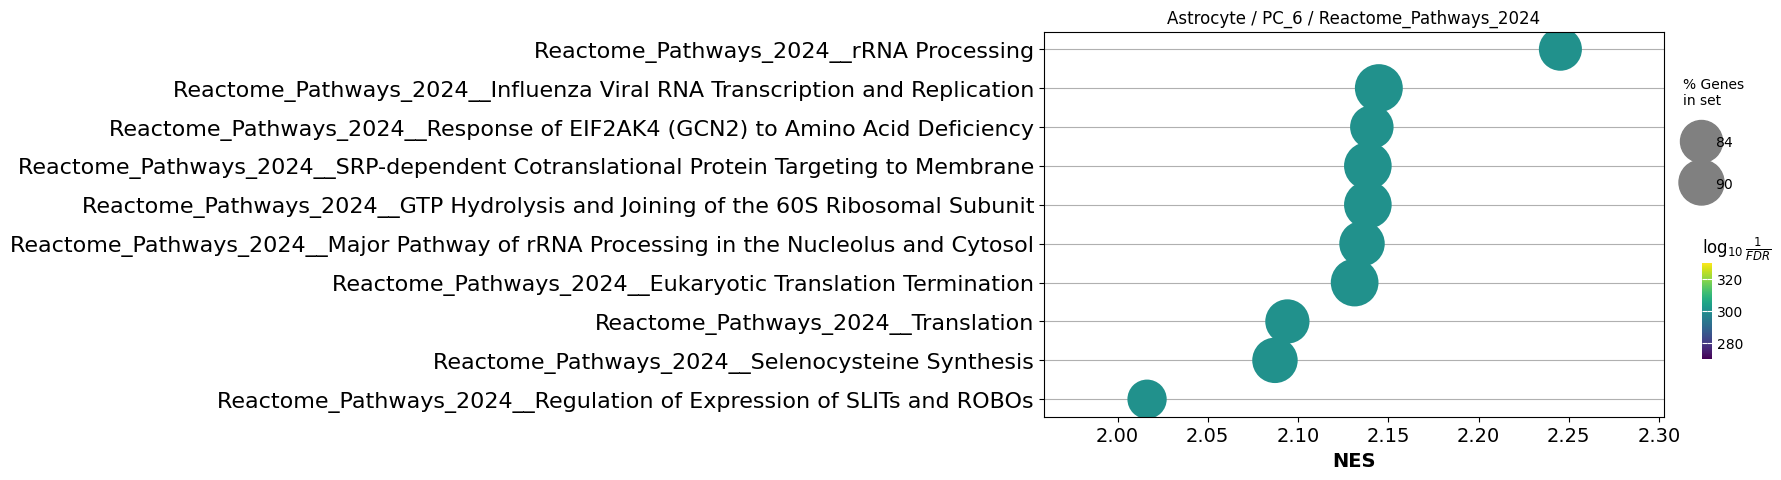


    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  10 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
1,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.064531,0.0
2,GO_Biological_Process_2025__Gene Expression (GO:0010467),2.062864,0.0
3,GO_Biological_Process_2025__Translation (GO:0006412),2.055108,0.0
6,GO_Biological_Process_2025__Ribonucleoprotein Complex Biogenesis (GO:0022613),1.972622,0.000196
5,GO_Biological_Process_2025__Ribosome Biogenesis (GO:0042254),1.984119,0.000245
8,GO_Biological_Process_2025__Macromolecule Biosynthetic Process (GO:0009059),1.934202,0.000489
12,GO_Biological_Process_2025__Ribosomal Small Subunit Biogenesis (GO:0042274),1.839487,0.008248
16,GO_Biological_Process_2025__rRNA Processing (GO:0006364),1.800529,0.018226
20,GO_Biological_Process_2025__Protein Metabolic Process (GO:0019538),1.780195,0.026422
23,GO_Biological_Process_2025__rRNA Metabolic Process (GO:0016072),1.759707,0.037871


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


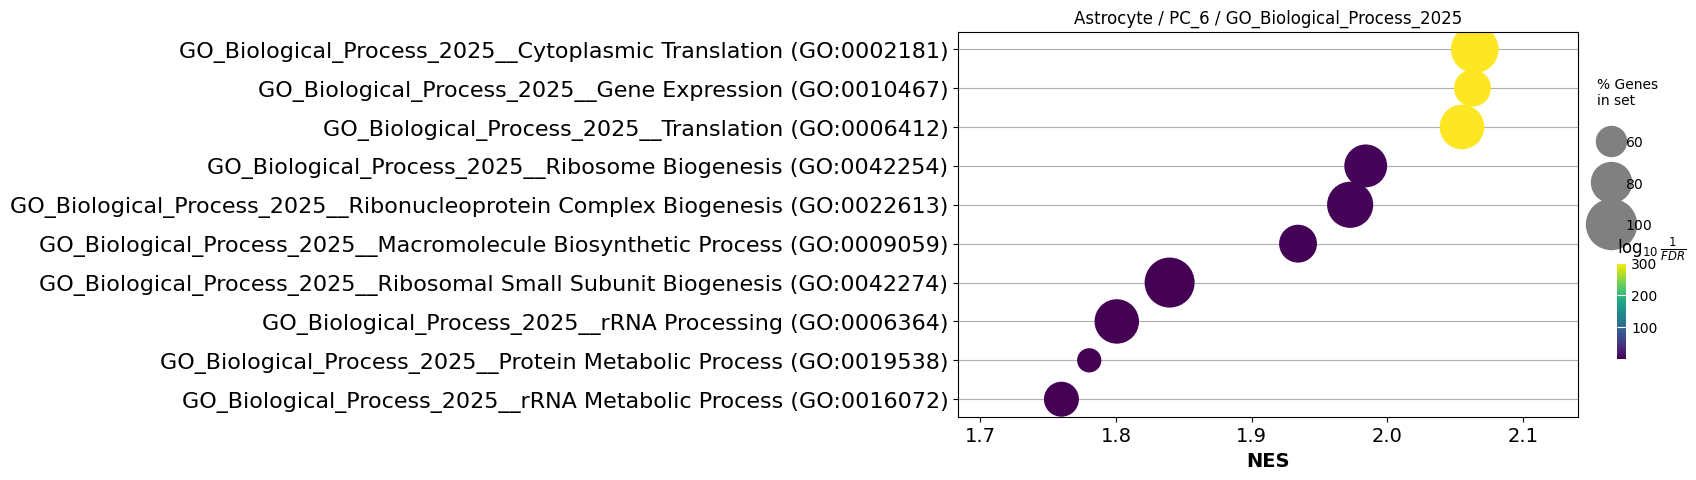


    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  30 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__YY1 ENCODE,2.034463,0.0
1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__MYC CHEA,1.960874,0.0
2,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__TAF1 ENCODE,1.947627,0.0
5,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__ATF2 ENCODE,1.833613,0.000856
4,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__TAF7 ENCODE,1.837463,0.001027
3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__MYC ENCODE,1.842697,0.001284
6,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__GABPA ENCODE,1.790233,0.001761
7,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__ZBTB33 ENCODE,1.762535,0.002311
9,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__CREB1 CHEA,1.737971,0.002465
8,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X__CREB1 ENCODE,1.741505,0.002739


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


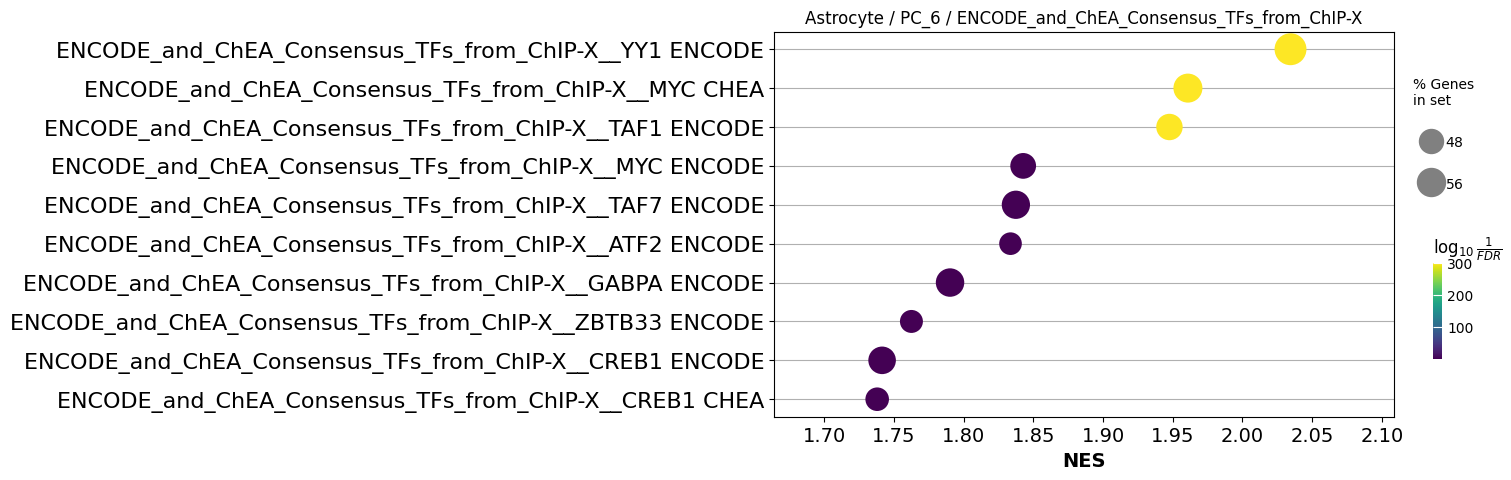


    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  3 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,TRRUST_Transcription_Factors_2019__SMAD4 mouse,-2.228341,0.001796
3,TRRUST_Transcription_Factors_2019__STAT3 human,-1.934652,0.044457
1,TRRUST_Transcription_Factors_2019__EGR1 mouse,-1.993071,0.044906


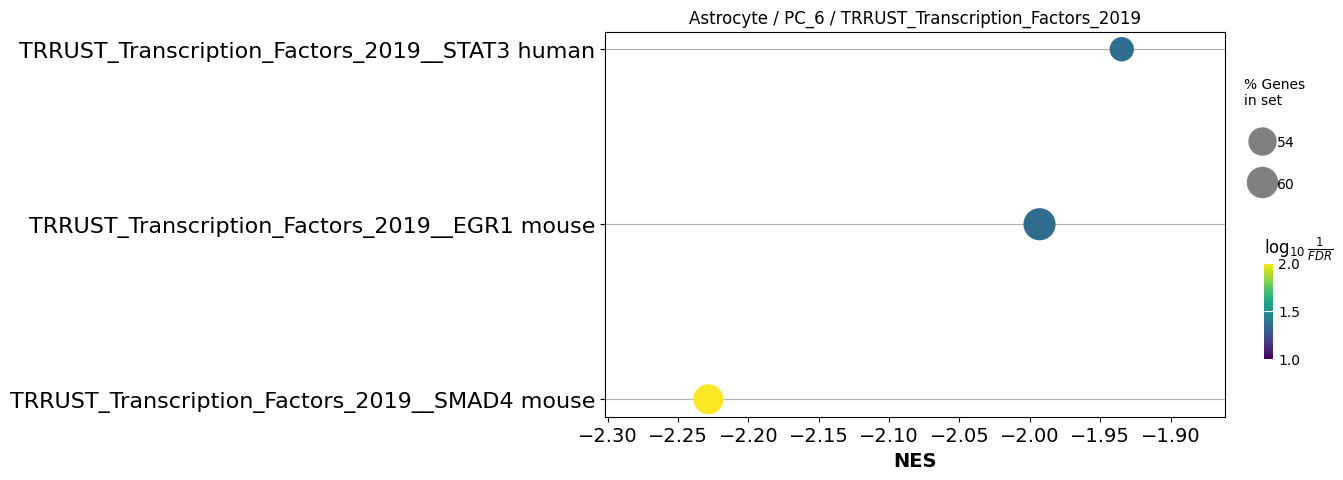

,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
1,PC_6,Oligodendrocyte_Cortisol,2,0.82,0.82,0.992,0.0001,"FKBP5, TSC22D3"
6,PC_6,Astrocyte_Cortisol,2,0.82,0.82,0.992,0.0001,"FKBP5, TSC22D3"
10,PC_6,General_Cortisol,3,1.33,19.66,0.804,0.0341,"FKBP5, TSC22D3, PER1"
8,PC_6,General_Mito,6,8.05,8.64,0.915,0.0000,"MT-CO1, MT-CO2, MT-ND1, MT-ND3, MT-ATP6, MT-CYB"
15,PC_6,Oligodendrocyte_Markers,2,10.48,10.48,0.896,0.0219,"MBP, PLP1"
3,PC_6,Astrocyte_GM,3,19.83,31.84,0.682,0.1451,"SLC1A2, SLC1A3, GJA1"
13,PC_6,General_lncRNA,3,21.93,30.74,0.693,0.1305,"MALAT1, NEAT1, XIST"
9,PC_6,General_Housekeeping,2,22.05,22.05,0.780,0.0971,"GAPDH, B2M"
0,PC_6,Oligodendrocyte_Reactive,2,23.57,23.57,0.765,0.1110,"FRY, HSPA1A"
12,PC_6,General_Stress_HSP,5,29.57,34.11,0.659,0.1126,"HSPA1A, HSPA1B, HSPB1, HSP90AA1, DNAJB1"



  ──────────────────────────────────────────────────
  FACTOR: PC_7
  ──────────────────────────────────────────────────


gene
DPP10      0.089929
CERS6      0.083999
DAAM2      0.079671
GPC6       0.075973
ALDH1A1    0.074301
             ...   
MAP3K19   -0.068838
TRPC6     -0.070101
DNAH11    -0.074444
SYNE1     -0.086062
LGR6      -0.089790
Name: rank_metric, Length: 3000, dtype: float64

2026-04-15 18:07:25,369 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  custom
    ────────────────────────────────────────
    [result] 9 pathways tested  →  0 significant (FDR ≤ 0.05)


...

    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  MSigDB_Hallmark_2020
    ────────────────────────────────────────
    [result] 48 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


2026-04-15 18:07:25,746 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  SynGO_2024
    ────────────────────────────────────────
    [result] 53 pathways tested  →  1 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,SynGO_2024__Ligand-Gated IC Activity Involved In Regulation Of Presynaptic Membrane Potential (GO:0099507) BP,1.75459,0.039962


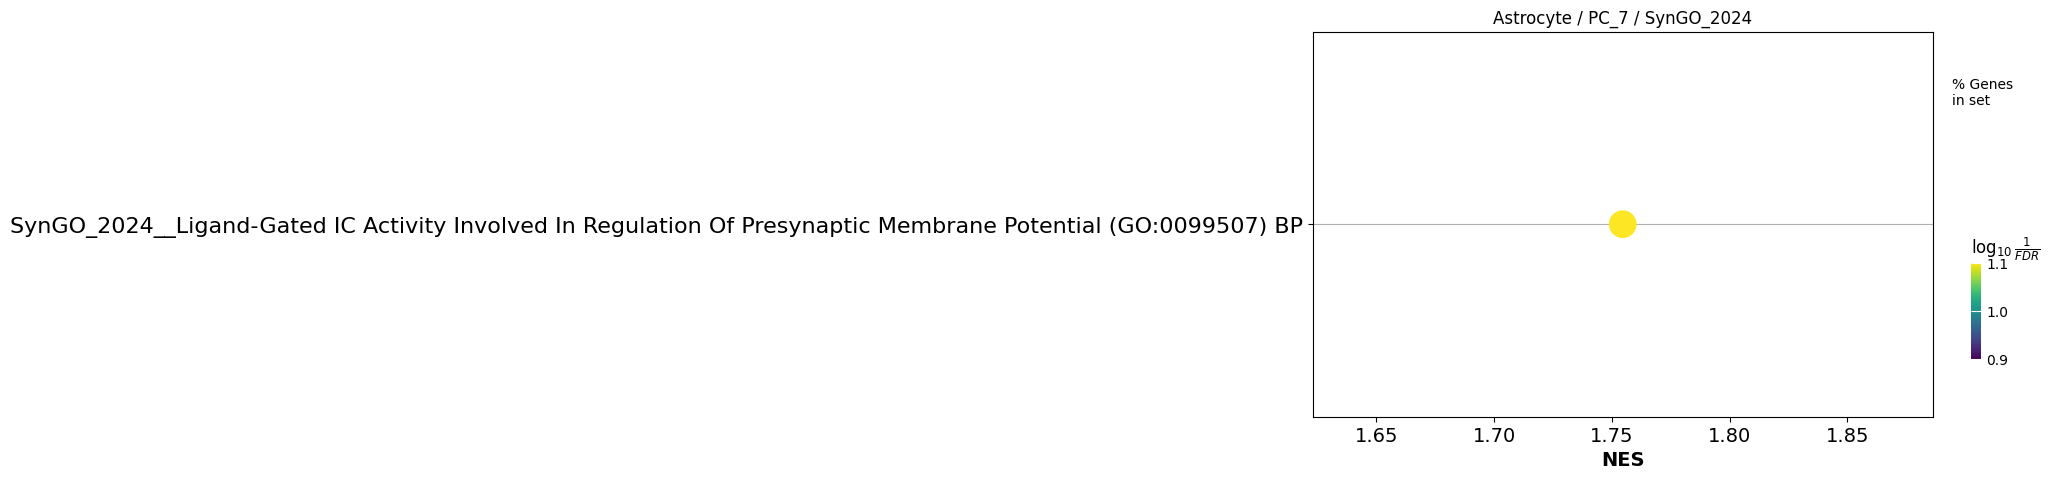

2026-04-15 18:07:26,402 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  Reactome_Pathways_2024
    ────────────────────────────────────────
    [result] 911 pathways tested  →  5 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,Reactome_Pathways_2024__rRNA Processing in the Mitochondrion,-2.366806,0.0
1,Reactome_Pathways_2024__FASTK Family Proteins Regulate Processing and Stability of Mitochondrial RNAs,-2.31839,0.0
2,Reactome_Pathways_2024__tRNA Processing in the Mitochondrion,-2.31839,0.0
3,Reactome_Pathways_2024__Mitochondrial RNA Degradation,-2.31839,0.0
4,Reactome_Pathways_2024__tRNA Processing,-2.233801,0.003042


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


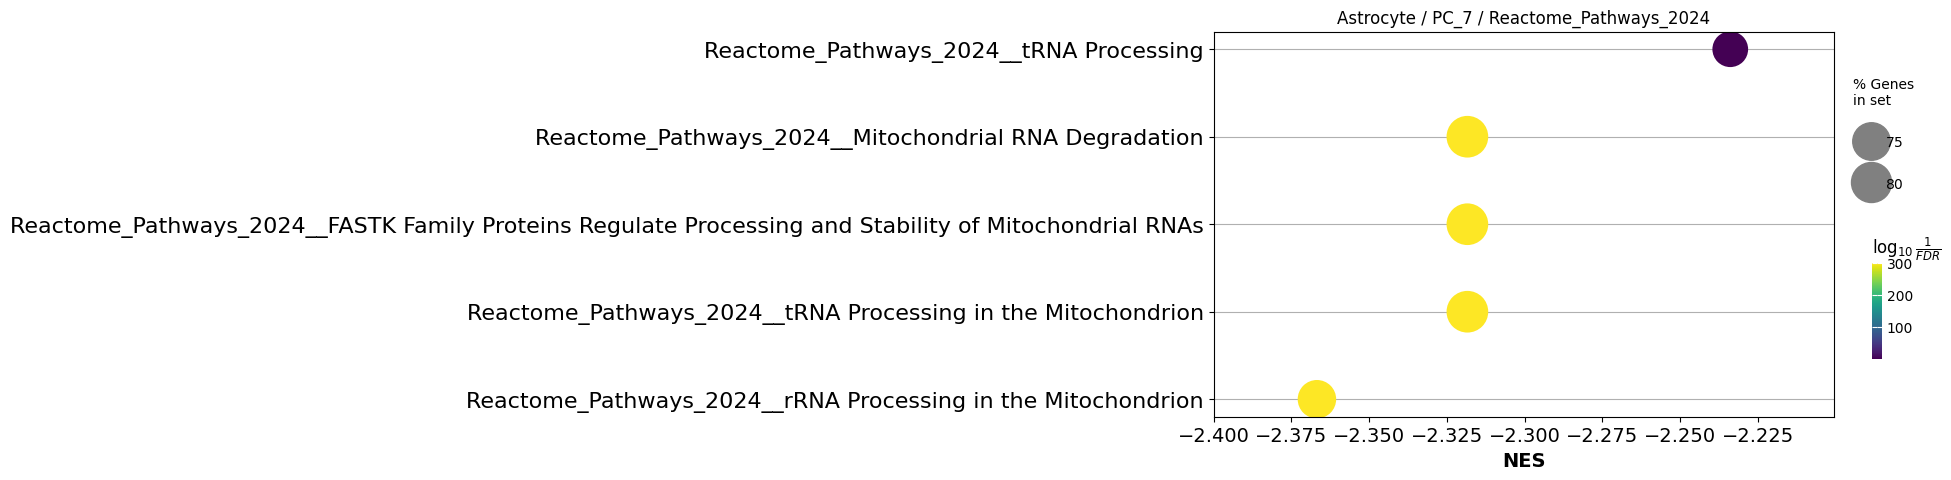

2026-04-15 18:07:28,992 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  GO_Biological_Process_2025
    ────────────────────────────────────────
    [result] 1610 pathways tested  →  13 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Cilium Movement (GO:0003341),-3.000338,0.0
1,GO_Biological_Process_2025__Axonemal Dynein Complex Assembly (GO:0070286),-2.531926,0.0
2,GO_Biological_Process_2025__Axoneme Assembly (GO:0035082),-2.318581,0.0
3,GO_Biological_Process_2025__Cilium-Dependent Cell Motility (GO:0060285),-2.229155,0.001194
4,GO_Biological_Process_2025__Outer Dynein Arm Assembly (GO:0036158),-2.175652,0.001911
5,GO_Biological_Process_2025__Determination of Left/Right Symmetry (GO:0007368),-2.155532,0.002229
6,GO_Biological_Process_2025__Cilium Movement Involved in Cell Motility (GO:0060294),-2.119988,0.003139
7,GO_Biological_Process_2025__Response to Unfolded Protein (GO:0006986),-2.081977,0.006688
8,GO_Biological_Process_2025__Epithelial Cilium Movement Involved in Extracellular Fluid Movement (GO:0003351),-2.004665,0.019533
9,GO_Biological_Process_2025__Spermatid Development (GO:0007286),-1.9913,0.021975


/tmp/ipykernel_632893/3831517346.py:129: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)


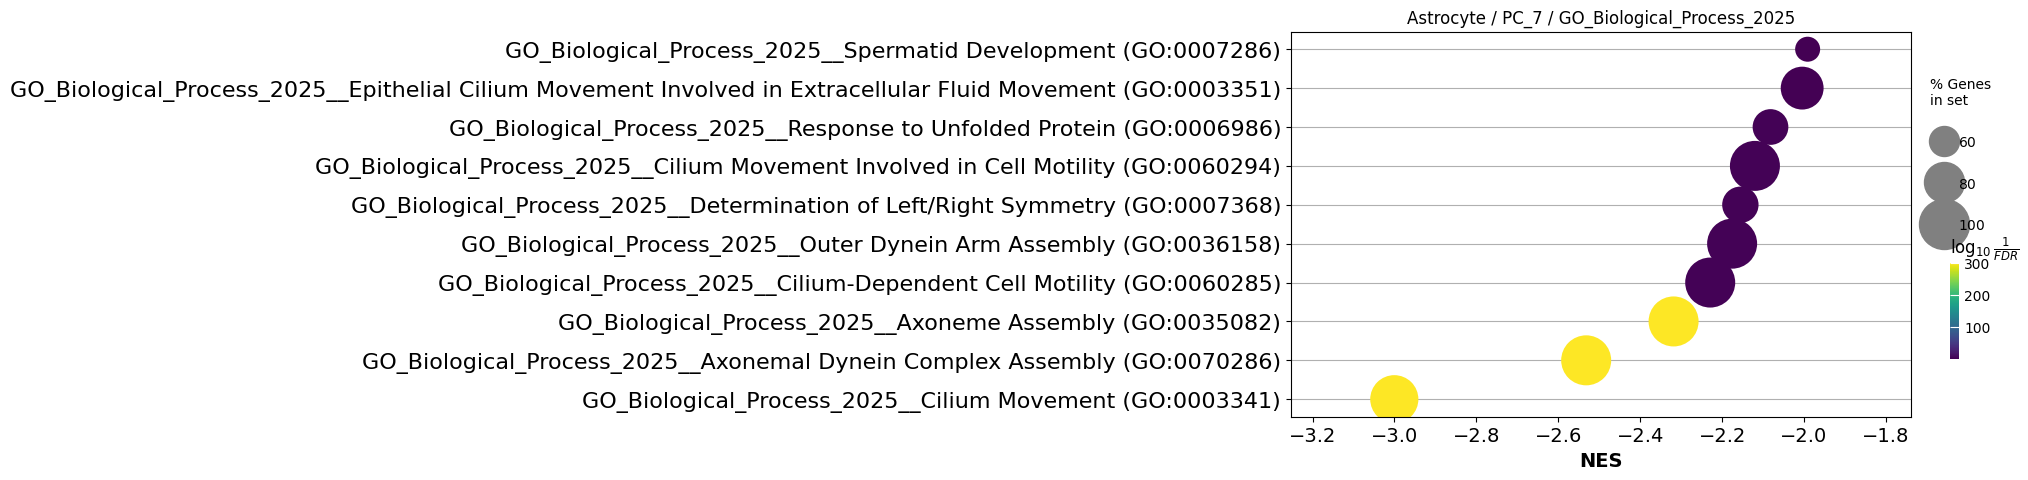

2026-04-15 18:07:33,288 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



    ────────────────────────────────────────
    GSEA  ▶  ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X
    ────────────────────────────────────────
    [result] 100 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


2026-04-15 18:07:33,770 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


    [plot]   Skipping dotplot — no significant terms

    ────────────────────────────────────────
    GSEA  ▶  TRRUST_Transcription_Factors_2019
    ────────────────────────────────────────
    [result] 199 pathways tested  →  0 significant (FDR ≤ 0.05)


,Term,NES,FDR q-val


    [plot]   Skipping dotplot — no significant terms


,factor,pathway,n_genes_found,median_pct,mean_pct,AUC,pval_exact,genes_found
7,PC_7,Microglia_DAM,2,9.62,9.62,0.904,0.0184,"CD9, APOE"
16,PC_7,Astrocyte_Markers,3,12.20,23.03,0.770,0.0548,"GFAP, S100B, SLC1A2"
9,PC_7,General_Housekeeping,2,17.13,17.13,0.829,0.0586,"GAPDH, B2M"
5,PC_7,Astrocyte_A2_Antiinflammatory,3,29.27,42.56,0.575,0.3359,"S100A10, EMP1, SPHK1"
2,PC_7,Astrocyte_WM,3,29.37,45.19,0.548,0.3925,"GFAP, CRYAB, VIM"
0,PC_7,Oligodendrocyte_Reactive,2,34.33,34.33,0.657,0.2356,"FRY, HSPA1A"
3,PC_7,Astrocyte_GM,3,53.90,60.17,0.398,0.7191,"SLC1A2, SLC1A3, GJA1"
15,PC_7,Oligodendrocyte_Markers,2,66.70,66.70,0.333,0.7781,"MBP, PLP1"
13,PC_7,General_lncRNA,3,69.73,63.08,0.369,0.7740,"MALAT1, NEAT1, XIST"
10,PC_7,General_Cortisol,3,76.03,79.91,0.201,0.9635,"FKBP5, TSC22D3, PER1"


In [ ]:
# Run only for factors
if TYPE_DEG in ["PCA_nebula", "cNMF_nebula"]:

    THR_FDR_GSEA=0.05  # FDR threshold for significant GSEA terms

    for SAVE_HEALTHY_PCA_RESULT, ct in _all_results:

        print(f"\n{'='*60}\n  CELL TYPE: {ct}\n{'='*60}")

        # 1. Load the factor × gene matrix
            # ATTENTION NUMBER OF GENES IS THE ONE USED TO CLAUCLTE THE FACOTRS (eg 3000 hvg for pca, 2000 hvg for cnmf)
        if TYPE_DEG == "PCA_nebula":
            matrix_path = f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv"
            if not os.path.exists(matrix_path):
                print(f"  [ERROR] Missing gene_loadings.csv for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(matrix_path, index_col=0)
            factor_cols = df_matrix.columns.tolist()

        elif TYPE_DEG == "cNMF_nebula":
            score_files = glob.glob(f"{SAVE_HEALTHY_PCA_RESULT}/cNMF_run_healthy/*.gene_spectra_score.*.txt")
            if not score_files:
                print(f"  [ERROR] No gene_spectra_score file found for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(score_files[0], sep="\t", index_col=0).T
            df_matrix.columns = [f"GEP_{i+1}" for i in range(df_matrix.shape[1])]
            factor_cols = df_matrix.columns.tolist()

        display(df_matrix.head())

        # Output directory
        img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "factors_investigation", "gsea")
        if os.path.exists(img_dir):
            shutil.rmtree(img_dir)
        os.makedirs(img_dir, exist_ok=True)

        #########################
        # Save top and bottom genes per factor
        #########################
        N_GENES = 20
        records = []
        for factor in factor_cols:
            series = df_matrix[factor].dropna()
            for rank, (gene, score) in enumerate(series.sort_values(ascending=False).head(N_GENES).items(), 1):
                records.append({"factor": factor, "direction": "top", "rank": rank, "gene": gene, "score": score})
            for rank, (gene, score) in enumerate(series.sort_values(ascending=False).tail(N_GENES).items(), 1):
                records.append({"factor": factor, "direction": "bottom", "rank": rank, "gene": gene, "score": score})
        df_genes = pd.DataFrame(records)
        save_path = os.path.join(SAVE_HEALTHY_PCA_RESULT, f"{N_GENES}_top_genes_per_pc.csv")
        df_genes.to_csv(save_path, index=False)
        display(df_genes)

        #########################
        # wchih factor correlate with QC
        #########################
        # SEE ALREADY CALCULTED CORR MATRIX

        #########################
        # Chekc with facotrs are signicnat epxlained by contion 
        #########################
        # SEE ALREADY CALCULATED

        # 2. Run GSEA prerank for each factor
        for factor in factor_cols:

            print(f"\n  {'─'*50}")
            print(f"  FACTOR: {factor}")
            print(f"  {'─'*50}")


            df_factor = df_matrix[[factor]].rename(columns={factor: "score"}).reset_index().rename(columns={"gene_symbol": GENE_COL})

            # Build ranked list from factor loadings/scores
                # attnention: do NOT remove noisy genes
                # attention: score alredy rpesnet
            ranked_series, df_rank = from_deg_df_to_df_rank(df_factor, GENE_COL=GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col="score", REMOVE_GENE_TOO_HIGH_INTERCEPT=False, REMOVE_RIBO_GENES_FROM_GSEA=False)
            display(ranked_series)

            factor_dir = os.path.join(img_dir, factor)
            os.makedirs(factor_dir, exist_ok=True)

            ####
            # GSEA ON  BIG PATHWAYS
            ###

            # Loop over each DB independently (FDR corrected within each DB)
            for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:

                try:
                    print(f"\n    {'─'*40}")
                    print(f"    GSEA  ▶  {db_name}")
                    print(f"    {'─'*40}")


                    # PCA scores --> pos and neg --> need std
                    # cNMF scores --> pos and neg
                        # gene_spectra_score (Z-scored): a negative score means the gene is less specific to this GEP relative to others — not that it's absent
                    score_type_gsea_factors = "std" if TYPE_DEG == "cNMF_nebula" else "std"

                    pre_res = gp.prerank(
                        rnk=ranked_series,
                        gene_sets=gene_sets,
                        score_type=score_type_gsea_factors, 
                        seed=42,
                        permutation_num=1000,
                        min_size=min_s,
                        max_size=max_s,
                        verbose=False,
                        threads=30,
                    )

                    df_gsea = pre_res.res2d.copy()
                    df_gsea = df_gsea.sort_values("FDR q-val")

                    df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy()

                    # Save full + significant results
                    df_gsea.to_csv(    f"{factor_dir}/{db_name}_gsea_all.csv", index=False)
                    df_gsea_sig.to_csv(f"{factor_dir}/{db_name}_gsea_sig.csv", index=False)

                    print(f"    [result] {len(df_gsea)} pathways tested  →  "
                          f"{len(df_gsea_sig)} significant (FDR ≤ {THR_FDR_GSEA})")

                    with pd.option_context("display.max_colwidth", None):
                        display(df_gsea_sig[["Term", "NES", "FDR q-val"]])

                    # Dotplot
                    if len(df_gsea_sig) == 0:
                        print(f"    [plot]   Skipping dotplot — no significant terms")
                    else:
                        try:
                            res2d_plot = df_gsea.copy()
                            res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)
                            dotplot(
                                res2d_plot,
                                column="FDR q-val",
                                cmap=plt.cm.viridis,
                                size=6,
                                figsize=(10, 5),
                                cutoff=THR_FDR_GSEA,
                                show_ring=False,
                                ofname=None,
                            )
                            plt.title(f"{ct} / {factor} / {db_name}")
                            plt.savefig(f"{factor_dir}/{db_name}_dotplot.png",
                                        dpi=150, bbox_inches="tight")
                            plt.show()
                            plt.close()
                        except Exception as plot_err:
                            print(f"    [plot]   Dotplot failed ({plot_err}), results already saved to CSV")

                except Exception as e:
                    print(f"    [ERROR] GSEA failed for {factor} / {db_name}: {e}")

            
            ####
            # GSEA ON SMALL PATHWAYS
            ###

            factor_results = []

            from scipy.stats import mannwhitneyu

            for pathway_name, genes in small_curated_pathways.items():

                genes_found = [g for g in genes if g in ranked_series.index]
                if not genes_found:
                    continue

                n       = len(ranked_series)
                ranks   = ranked_series.rank(ascending=False)
                in_set  = ranked_series[ranked_series.index.isin(genes_found)] # loading scores of your 2–3 pathway genes, these are the raw scores, not ranks. scipy handles the ranking internally.
                out_set = ranked_series[~ranked_series.index.isin(genes_found)]

                # ranks for median
                gene_ranks  = ranks[genes_found]
                median_pct  = round(gene_ranks.median() / n * 100, 2)
                mean_pct    = round(gene_ranks.mean()   / n * 100, 2)

                # Mann-Whitney → AUC + p-value
                alternative = 'two-sided' if TYPE_DEG == 'cNMF_nebula' else 'two-sided'
                stat, pval = mannwhitneyu(in_set, out_set, alternative=alternative, method='exact')
                #these are the raw scores, not ranks. scipy handles the ranking internally.
                    #exact --> It takes every possible pair of (one gene from in_set, one gene from out_set) and asks: in how many pairs does the in_set gene score higher?
                    #greater --> "Is in_set stochastically greater than out_set?"
                    # stat = the U statistic = number of pairs where in_set wins
                    #pval = probability of getting a U this large by chance if the genes were randomly placed
                    #Note that with 'two-sided', the AUC formula needs adjustment: AUC from a two-sided MWU is still stat / (len(in_set) * len(out_set)), but values < 0.5 now indicate enrichment at the negative end.
                auc        = round(stat / (len(in_set) * len(out_set)), 3)
                    #AUC is just U normalised to [0, 1]:

                factor_results.append({
                    "factor":        factor,
                    "pathway":       pathway_name,
                    "n_genes_found": len(genes_found),
                    "median_pct":    median_pct,
                    "mean_pct":      mean_pct,
                    "AUC":           auc,        # ← main effect size, 0.5 = null
                    "pval_exact":    round(pval, 4),
                    "genes_found":   ", ".join(genes_found),
                })

            df_median = pd.DataFrame(factor_results).sort_values("median_pct")

            from statsmodels.stats.multitest import multipletests
            df_median["padj"] = multipletests(df_median["pval_exact"], method="fdr_bh")[1]

            df_median.to_csv(f"{factor_dir}/small_pathways_median_rank.csv", index=False)
            display(df_median)

        #break

# Scatterplot logFC differt methods

In [ ]:
# ── Scatter: logFC(PCA_nebula) vs logFC(baseline_nebula / cNMF_nebula) ───────
# For each regular cell type in the selected tissue, scatter-plot the per-gene
# logFC from two DEG methods so we can see how much the PCA covariates
# move the effect estimates relative to the baseline model (and cNMF if available).

from scipy.stats import pearsonr

TISSUE_SCATTER = TISSUE   # override here if needed, e.g. "Striatum"

BASE_PCA      = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/PCA_nebula"
BASE_BASELINE = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/baseline_nebula"
BASE_CNMF     = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/cNMF_nebula"

def _load_deg(base_folder, ct):
    #\"\"\"Load deg_results.csv for one cell type; returns None if file is missing.\"\"\"
    path = os.path.join(base_folder, ct, "deg_results.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path).dropna(subset=[PVAL_COL, LOGFC_COL])
    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)  # ln → log2

    
    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        df = df[df["logFC_(Intercept)"] >= -20]
    df["_padj"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]
    return df[[GENE_COL, LOGFC_COL, "_padj"]].copy()


def _scatter_comparison(ax, df_x, df_y, label_x, label_y, pval_thr=PVAL_THR, logfc_thr=LOGFC_THR):
    #\"\"\"Scatter logFC(x) vs logFC(y) on ax, coloured by significance.\"\"\"
    merged = df_x.merge(df_y, on=GENE_COL, suffixes=("_x", "_y"))
    if merged.empty:
        ax.text(0.5, 0.5, "no common genes", ha="center", va="center", transform=ax.transAxes)
        return

    sig_x   = merged["_padj_x"] <= pval_thr
    sig_y   = merged["_padj_y"] <= pval_thr
    both    =  sig_x &  sig_y
    only_x  =  sig_x & ~sig_y
    only_y  = ~sig_x &  sig_y
    neither = ~sig_x & ~sig_y

    kw = dict(alpha=0.5, s=8, linewidths=0)
    ax.scatter(merged.loc[neither,  f"{LOGFC_COL}_x"], merged.loc[neither,  f"{LOGFC_COL}_y"], color="lightgrey",  label="not sig",         **kw)
    ax.scatter(merged.loc[only_x,   f"{LOGFC_COL}_x"], merged.loc[only_x,   f"{LOGFC_COL}_y"], color="steelblue",  label=f"sig {label_x}",  **kw)
    ax.scatter(merged.loc[only_y,   f"{LOGFC_COL}_x"], merged.loc[only_y,   f"{LOGFC_COL}_y"], color="darkorange", label=f"sig {label_y}",  **kw)
    ax.scatter(merged.loc[both,     f"{LOGFC_COL}_x"], merged.loc[both,     f"{LOGFC_COL}_y"], color="firebrick",  label="sig both",        **kw)

    # diagonal reference
    lim = max(merged[[f"{LOGFC_COL}_x", f"{LOGFC_COL}_y"]].abs().max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8, ls="--", zorder=0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Pearson r on all genes
    r, p = pearsonr(merged[f"{LOGFC_COL}_x"], merged[f"{LOGFC_COL}_y"])
    ax.set_xlabel(f"logFC  [{label_x}]", fontsize=9)
    ax.set_ylabel(f"logFC  [{label_y}]", fontsize=9)
    ax.text(0.03, 0.97, f"r = {r:.2f}  n = {len(merged)}", transform=ax.transAxes,
            va="top", fontsize=8, color="dimgray")
    ax.legend(fontsize=7, markerscale=2, loc="lower right")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.axvline(0, color="grey", lw=0.5, ls=":")


# ── collect regular cell types from PCA folder ─────────────────────────────
if not os.path.exists(BASE_PCA):
    print(f"ERROR: PCA results not found: {BASE_PCA}")
else:
    cell_types = sorted([
        ct for ct in os.listdir(BASE_PCA)
        if os.path.isdir(os.path.join(BASE_PCA, ct))
        and ct not in ("_summary",)
        and "_by_" not in ct
    ])

    has_cnmf  = os.path.exists(BASE_CNMF)
    n_cols    = 2 if has_cnmf else 1
    n_rows    = len(cell_types)
    fig_h     = max(3.5 * n_rows, 4)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, fig_h),
                             squeeze=False)

    for row, ct in enumerate(cell_types):
        df_pca = _load_deg(BASE_PCA, ct)

        # ── col 0: PCA vs Baseline ──────────────────────────────────────────
        ax0 = axes[row, 0]
        ax0.set_title(f"{ct}  |  PCA vs Baseline", fontsize=9)
        df_base = _load_deg(BASE_BASELINE, ct)
        if df_pca is None or df_base is None:
            ax0.text(0.5, 0.5, "missing results", ha="center", va="center", transform=ax0.transAxes)
        else:
            _scatter_comparison(ax0, df_pca, df_base, "PCA", "Baseline")

        # ── col 1: PCA vs cNMF (optional) ───────────────────────────────────
        if has_cnmf:
            ax1 = axes[row, 1]
            ax1.set_title(f"{ct}  |  PCA vs cNMF", fontsize=9)
            df_cnmf = _load_deg(BASE_CNMF, ct)
            if df_pca is None or df_cnmf is None:
                ax1.text(0.5, 0.5, "missing results", ha="center", va="center", transform=ax1.transAxes)
            else:
                _scatter_comparison(ax1, df_pca, df_cnmf, "PCA", "cNMF")

    fig.suptitle(f"logFC comparison across DEG methods  |  {TISSUE_SCATTER}", fontsize=12, y=1.002)
    plt.tight_layout()
    plt.savefig(
        f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE_SCATTER}/logFC_method_scatter.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
